<h1 style = "color : #0EE071; text-align : center;"><em>Where should I live?</em> - Data Wrangling & Analysis Notebook</h1>
<p style = "font-size : 16px; text-align: center;">This notebook is dedicated to the exploration, wrangling and analysis of the <code>city_data</code> dataset</p>
<br>
<p style = "font-size : 12px; text-align: center;"><b>NOVA IMS</b></p>
<p style = "font-size : 10px; text-align: center;">Programming for Data Science</p>
<p style = "font-size : 10px; text-align: center;">Diogo Gonçalves, João Marques, Juan Mendes & Gustavo Franco</p>
<br>

<h2  style = "color : #0EE071;"> Imports</h2>

In [6]:
import pandas as pd

import numpy as np

import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns

import plotly
import plotly.express as px

import sys
import warnings
import datetime as dt

warnings.filterwarnings('ignore')

In [706]:
#!pip show numpy

In [707]:
#!pip show pandas

In [708]:
#!pip show matplotlib

In [709]:
#!pip show seaborn

<hr style = "border: 3px solid #0EE071;">
<h2 style = "color : #0EE071;">Dataset Reading </h2>
<p style = "font-size : 15px;">Reading of dataset from <code>city_data.csv</code> file</p>
<p>The dataset is in a <code>.csv</code> file, and uses <code>|</code> as a separator. The first row of the file is also blank, so we read it using <code>skiprows = 1</code>. </p>

In [710]:
city_data = pd.read_csv("city_data.csv", sep = "|", skiprows = 1)
city_data.head()

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
0,"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00
1,"Salzburg, Austria",243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03 00:00:00
2,"Brussels, Belgium",681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22 00:00:00
3,"Antwerp, Belgium",928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09 00:00:00
4,"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17 00:00:00


<hr style = "border: 3px solid #0EE071;">
<h2  style = "color : #0EE071;">Dataset Strucure</h2>
<p style = "font-size : 15px;">Exploration of the structure of <code>city_data</code> dataset</p>

In [711]:
city_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   City                             86 non-null     object 
 1   Population Density               85 non-null     float64
 2   Population                       86 non-null     int64  
 3   Working Age Population           85 non-null     float64
 4   Youth Dependency Ratio           86 non-null     float64
 5   Unemployment Rate                85 non-null     float64
 6   GDP per Capita                   85 non-null     float64
 7   Days of very strong heat stress  86 non-null     int64  
 8   Main Spoken Languages            85 non-null     object 
 9   Average Monthly Salary           86 non-null     int64  
 10  Avgerage Rent Price              86 non-null     int64  
 11  Average Cost of Living           86 non-null     int64  
 12  Average Price Groceries 

In [712]:
city_data.describe()

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries
count,85.000000,8.600000e+01,8.500000e+01,86.000000,85.000000,85.000000,86.000000,86.000000,86.000000,86.000000,6.000000
mean,1115.141176,1.754370e+06,1.158294e+06,24.096860,6.667059,51750.269647,4.348837,2434.488372,1070.104651,1808.383721,225.833333
std,2542.778533,1.843133e+06,1.232534e+06,3.266421,4.553632,21495.617843,10.038476,1188.602984,498.964576,727.999680,97.890585
min,65.000000,7.389500e+04,4.635900e+04,19.300000,1.400000,10089.920000,0.000000,750.000000,100.000000,800.000000,100.000000
25%,304.000000,5.281185e+05,3.580200e+05,21.425000,3.700000,38664.000000,0.000000,1412.500000,800.000000,1300.000000,147.500000
50%,548.000000,1.178397e+06,7.337940e+05,23.150000,5.300000,49329.000000,1.000000,2400.000000,1050.000000,1665.000000,243.000000
75%,1020.000000,2.315896e+06,1.534225e+06,25.925000,8.100000,63083.000000,3.000000,3200.000000,1250.000000,2100.000000,295.750000
max,20983.000000,1.239654e+07,8.274794e+06,37.800000,23.000000,146094.000000,59.000000,6636.000000,3190.000000,4862.000000,340.000000


<h3>Data Structure Overview</h3>

<ul>
<li>The dataset contains <b>13 columns</b> and <b>85 rows</b>.</li>
<li>Each row represents a <b>European city</b>.</li>
<li>The variable <code>City</code> stores both the name of the city and its country.</li>
<li>The variables <code>Population Density</code>, <code>Working Age Population</code>, <code>Unemployment Rate</code>, <code>GDP per capita</code> and <code>Main Spoken Languages</code> <b>have 1 missing value</b>.</li>
<li>Only 6 cities have a known <code>Average Price Groceries</code> in this dataset.</li>
<li>This dataset has a memory usage of aroud 9.5 KB.</li>
</ul> </p>

<hr style = "border: 3px solid #0EE071;">
<h2 style = "color : #0EE071;">Variable Outline</h2>
<p style = "font-size : 16px;">Exploration of each variable independently.</p>
<br>

<h3><code>City</code></h3>
<p style = "font-size : 15px;"><b>Name of the city and country. Acts as unique identifier.</b></p>
<p><b>Data Type:</b> object/string</p>
<p><b>Missing Values:</b> 0</p>

<h4>Search for duplicates, if any:</h4>
<p>This is useful, as this variable acts as a unique identifier (no cities have the same name and are from the same country), it will guide us towards duplicate rows.</p>

In [713]:
int(city_data['City'].duplicated().sum()) #if we do not use int(...), the result will be presented with np.int(...) as it is a result of .sum()

2

<p>By checking the sum of the duplicated rows, we can see that there are two rows that are duplicated. Therefore, we have to see what are the duplicated rows:</p>

In [714]:
city_data[city_data['City'].duplicated(keep=False)]

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
15,Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,46548.0,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00
16,Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,46548.0,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00
32,"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,27694.0,0,"Spanish, English",2200,1312,1400,NaN,2023-11-27 00:00:00
33,"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,27694.0,0,"Spanish, English",2200,1312,1400,NaN,2023-11-27 00:00:00


In [715]:
city_data.iloc[15,:] == city_data.iloc[16,:] # Checking if rows 15 and 16 are indeed duplicated

City                                True
Population Density                  True
Population                          True
Working Age Population              True
Youth Dependency Ratio              True
Unemployment Rate                   True
GDP per Capita                      True
Days of very strong heat stress     True
Main Spoken Languages               True
Average Monthly Salary              True
Avgerage Rent Price                 True
Average Cost of Living              True
Average Price Groceries            False
Last Data Update                    True
dtype: bool

In [716]:
city_data.iloc[32,:] == city_data.iloc[33,:] # Checking if rows 32 and 33 are indeed duplicated

City                                True
Population Density                  True
Population                          True
Working Age Population              True
Youth Dependency Ratio              True
Unemployment Rate                   True
GDP per Capita                      True
Days of very strong heat stress     True
Main Spoken Languages               True
Average Monthly Salary              True
Avgerage Rent Price                 True
Average Cost of Living              True
Average Price Groceries            False
Last Data Update                    True
dtype: bool

<p style = "border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
Here we can see that <code>Berlin. Germany</code> (in rows indexes 15 and 16) and <code>Malaga, Spain</code> (in rows indexes 32 and 33) are duplicate.
We can also tell that the two pairs of rows are completly duplicated (on all columns). As the result of their comparison is <code>True</code> for all columns, excluding <code>Average Price Groceries</code> whose values are both null.</p>
<br>

<p>Let's drop those two duplicated rows:</p>

In [717]:
city_data = city_data.drop(16)
city_data = city_data.drop(33)

In [718]:
city_data = city_data.reset_index(drop = True)

<p>Checking:</p>

In [719]:
city_data.iloc[13:17,:]

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
13,"Prague, Czechia",388.0,2231212,1445800.0,26.2,1.4,64996.0,1,"Czech, English",1860,100,1590,NaN,2024-12-05 00:00:00
14,"Ostrava, Czechia",499.0,711860,464578.0,23.0,3.7,30105.0,0,Czech,1520,500,1100,NaN,2023-09-21 00:00:00
15,Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,46548.0,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00
16,"Hamburg, Germany",461.0,3315036,2181857.0,21.5,3.2,61058.0,0,"German, English, Turkish",3500,1100,2100,NaN,2024-07-10 00:00:00


In [720]:
city_data.iloc[30:34,:]

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
30,"Seville, Spain",330.0,1549641,1037225.0,25.0,21.6,30004.0,53,Spanish,2300,650,1150,NaN,2024-09-01 00:00:00
31,"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,27694.0,0,"Spanish, English",2200,1312,1400,NaN,2023-11-27 00:00:00
32,"Tallinn, Estonia",2469.0,390860,253977.0,26.9,3.5,49329.0,0,"Estonian, Russian, English",1700,700,1600,NaN,2023-08-23 00:00:00
33,"Helsinki, Finland",322.0,1507140,1004835.0,25.1,6.6,59502.0,0,"Finnish, Swedish, English",3900,1050,2050,NaN,2023-09-12 00:00:00


<h4>What are the separators between the City name and Country name?</h4>
<p>Using the .head() attribute we could see the variable <code>City</code> being the City name followed by the Country it is in, with a comma separiting them. In the duplicates, we had an example of a point being used for the separated. Are there any more separators used?</p>

In [721]:
city_data[~city_data['City'].str.contains(', ', regex=False) & ~city_data['City'].str.contains('. ', regex=False)]

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
12,Lemesos;Cyprus,190.0,262238,173906.0,23.06,11.2,NaN,0,"Greek, English, Russian",2500,1400,2300,NaN,2023-08-14 00:00:00


<p>We have filtered the ones that don't have any comma or point and found only <code>Lemesos;Cyprus</code> that uses semicolon. Now let's see how many (and which ones) use comma and how many use point:</p>

In [722]:
city_data[city_data['City'].str.contains(',', regex=False)]

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
0,"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00
1,"Salzburg, Austria",243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03 00:00:00
2,"Brussels, Belgium",681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22 00:00:00
3,"Antwerp, Belgium",928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09 00:00:00
4,"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,"Stockholm, Sweden",334.0,2344124,1534225.0,28.5,6.2,70950.0,0,"Swedish, English",2700,1400,2300,NaN,2024-09-11 00:00:00
80,"Gothenburg, Sweden",245.0,1037675,672152.0,28.2,6.3,49588.0,0,"Swedish, English",2500,1200,2100,NaN,2023-03-10 00:00:00
81,"Malmo, Sweden",368.0,680335,436271.0,29.4,9.2,44387.0,0,"Swedish, English",2400,1100,2000,NaN,2024-07-07 00:00:00
82,"Ankara, Turkiye",1922.0,4843511,3417691.0,30.0,14.4,38916.0,3,Turkish,900,450,900,309.0,2023-06-08 00:00:00


In [723]:
city_data[city_data['City'].str.contains('.', regex=False)]

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
15,Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,46548.0,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00


<p style = "border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
Concluding that <code>Berlin. Germany</code> is the only entry using a point, <code>Lemesos;Cyprus</code> is the only using a semicolon and all the other 83 rows (82 cities, as Malaga is duplicate) use a comma.</p>
<br>

<p>Let's then replace those separators with the most common one, the comma:</p>

In [724]:
city_data['City'] = city_data['City'].str.replace('. ', ', ', regex=False) #to deal with the 'Berlin' case
city_data['City'] = city_data['City'].str.replace(';', ', ', regex=False) #to deal with the 'Lemesos' case

<p>Cheking:</p>

In [725]:
city_data[city_data['City'].isin(['Berlin, Germany', 'Lemesos, Cyprus'])]

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
12,"Lemesos, Cyprus",190.0,262238,173906.0,23.06,11.2,NaN,0,"Greek, English, Russian",2500,1400,2300,NaN,2023-08-14 00:00:00
15,"Berlin, Germany",304.0,5303922,3481212.0,21.30,4.7,46548.0,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00


<h4>Is always the same order <code>City, Country</code>? Can we split it?</h4>
<p>As there is no automated way to detect this, by seeing all the dataframe, we can tell that Athens is inserted as <code>Greece, Athens</code>.</p>
<p>We should then split the name of the city from the country, for further analysis.</p>

In [726]:
pd.set_option('display.max_rows', None)

In [727]:
city_data

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
0,"Vienna, Austria",310.0,2983513,2018818.0,20.10,10.2,55770.00,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00
1,"Salzburg, Austria",243.0,375489,250472.0,20.30,3.0,66689.00,0,German,3200,1100,2186,NaN,2023-11-03 00:00:00
2,"Brussels, Belgium",681.0,3284548,2137425.0,27.50,10.7,62500.00,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22 00:00:00
3,"Antwerp, Belgium",928.0,1139663,723396.0,27.70,6.2,57595.00,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09 00:00:00
4,"Gent, Belgium",552.0,645813,417832.0,24.80,NaN,53311.00,2,"Dutch, French",2400,827,1200,120.0,2023-07-17 00:00:00
5,"Bruges, Belgium",840.0,119765,74600.0,25.63,5.6,63083.00,0,"Dutch, French",2700,1250,1708,NaN,2023-10-25 00:00:00
6,"Sofia, Bulgaria",272.0,1553106,1043522.0,21.40,2.3,43563.00,0,"Bulgarian, English, Turkish",1300,450,1100,NaN,2024-02-11 00:00:00
7,"Dobrich, Bulgaria",640.0,73895,46359.0,22.85,4.6,10089.92,0,"Bulgarian, Turkish",1200,400,1100,NaN,2023-12-30 00:00:00
8,"Zurich, Switzerland",1058.0,1384728,939270.0,22.30,4.7,80431.00,4,"German, English",6636,3190,4862,NaN,2023-05-06 00:00:00
9,"Geneva, Switzerland",1112.0,597269,404313.0,23.80,9.9,83747.00,1,"French, English",5794,2818,4263,NaN,2024-09-28 00:00:00


In [728]:
pd.reset_option('display.max_rows')

<p style = "border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
Concluding that <code>Greece, Athens</code> is the only entry tht doesn't follow the usual order, thus we will have to invert it.</p>
<br>

<p>Let's now separate this column <code>City</code> into two different variables: <code>City</code> and <code>Country</code>.</p>

In [729]:
# Creating 2 new columns based on the split ', '
city_data[['City_Name', 'Country_Name']] = city_data['City'].str.split(', ', expand=True)

In [730]:
# Dropping old column
city_data = city_data.drop(columns = ['City'])

In [731]:
# Renaming columns, for simplicity
city_data = city_data.rename(columns={'City_Name': 'City', 'Country_Name': 'Country'})

In [732]:
# Swapping the 'Greece, Athens' case:

athens_case = city_data['City'] == 'Greece'

# Set the 'City' column to 'Athens'
city_data.loc[athens_case, 'City'] = 'Athens'

# Set the 'Country' column to 'Greece'
city_data.loc[athens_case, 'Country'] = 'Greece'

<p>Checking:</p>

In [733]:
city_data.head()

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country
0,310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00,Vienna,Austria
1,243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03 00:00:00,Salzburg,Austria
2,681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22 00:00:00,Brussels,Belgium
3,928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09 00:00:00,Antwerp,Belgium
4,552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17 00:00:00,Gent,Belgium


In [734]:
city_data.loc[city_data['City'] == 'Athens']

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country
43,1829.0,3530371,2287174.0,22.0,17.2,38580.0,17,"Greek, English",1050,600,1200,NaN,2024-07-16 00:00:00,Athens,Greece


<h4>Are there any spaces before or after the name of the cities and countries?</h4>
<p>We have cases like <code>The Hague</code> where in the middle of the same of the city there is a correct spacing. Nevertheless, we may have cases of spaces before or after the names, let's correct that unsing .str.strip().</p>

In [735]:
city_data['City'] = city_data['City'].str.strip()
city_data['Country'] = city_data['Country'].str.strip()

<h4>Are City names the most correct ones? Can we make them more correct?</h4>
<p>By previous analysis, we came across names such as <code>Frankfurt</code> (should be 'Frankfurt am Main') and <code>Malta</code> (which is a country, there is no city called 'Malta').</p>

<p>For the case of <code>Frankfurt</code>, we can simply change the name to <code>Frankfurt am Main</code>:

In [736]:
city_data.loc[city_data['City'] == 'Frankfurt', 'City'] = 'Frankfurt am Main'

In [737]:
city_data.loc[city_data['City'] == 'Frankfurt am Main']

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country
19,631.0,2710501,1791435.0,22.0,3.2,69372.0,6,"German, English",3800,1300,2350,NaN,2023-02-04 00:00:00,Frankfurt am Main,Germany


As for <code>Malta</code>, we cannot be sure about which city in Malta it is refering to. Let's try to see the <code>Malta</code> column:

In [738]:
city_data.loc[city_data['City'] == 'Malta']

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country
60,1845.0,456490,309610.0,20.2,3.7,44781.0,0,"Maltese, English",1450,1000,1400,NaN,2024-02-28 00:00:00,Malta,Malta


<p>By checking the <code>Population</code>, we can see it matches 'Valletta' population. 'Valletta' is the capital and main city in the country of Malta, therefore it must be what this row is refering to.</p>
<p>Arriving here, we have two options: wheater we drop this row (as we are not 100% sure about which city it is refring to), or we assume it is refering to 'Valletta'. As we have some proof that this migh be 'Valletta' and to not discard such a unique place in Europe like the island of Malta, we chose to assume 'Valletta'.</p>

In [739]:
city_data.loc[city_data['City'] == 'Malta', 'City'] = 'Valletta'

In [740]:
city_data.loc[city_data['City'] == 'Valletta']

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country
60,1845.0,456490,309610.0,20.2,3.7,44781.0,0,"Maltese, English",1450,1000,1400,NaN,2024-02-28 00:00:00,Valletta,Malta


<h4>Data Type Evaluation</h4>
<p>The original data type is <code>object</code>, and as we splitted the original column, into two, they now have both the same data type.</p>
<p>Are there any data types more useful for each case?</p>

<h5><code>Country</code></h5>
<p>As there can be more than one city in each country, the values of <code>Country</code> may not be unique. For a more memory efficient dataset, we should change the data type to <code>category</code>:</p>

In [741]:
city_data['Country'] = city_data['Country'].astype('category')

Check:

In [742]:
city_data['Country'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 84 entries, 0 to 83
Series name: Country
Non-Null Count  Dtype   
--------------  -----   
84 non-null     category
dtypes: category(1)
memory usage: 1.5 KB


<h5><code>City</code></h5>
<p>As for the cities, we know that they are unique, so we will have 84 different cities. All of their names are strings, so we can change their data type to <code>string</code>:</p>

In [743]:
city_data['City'] = city_data['City'].astype('string')

Check:

In [744]:
city_data['City'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 84 entries, 0 to 83
Series name: City
Non-Null Count  Dtype 
--------------  ----- 
84 non-null     string
dtypes: string(1)
memory usage: 804.0 bytes


<h3><code>Population Density</code></h3>
<p style = "font-size : 15px;"><b>Number of inhabitants per km2.</b></p>
<p><b>Data Type:</b> float64</p>
<p><b>Missing Values:</b> 1</p>

In [745]:
city_data['Population Density'].describe()

count       83.000000
mean      1131.469880
std       2571.287365
min         65.000000
25%        293.500000
50%        548.000000
75%       1039.000000
max      20983.000000
Name: Population Density, dtype: float64

<h4>Search for the missing value:</h4>

In [746]:
city_data[city_data['Population Density'].isna()]

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country
29,NaN,1748142,1162828.0,22.6,13.7,33570.0,5,Spanish;Valencian,2400,1190,1300,NaN,2023-06-04 00:00:00,Valencia,Spain


<p style = "border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
Concluding that <code>Valencia</code> is the city that doesn't have a known value for <code>Population Density</code>.</p>

<h4>Search for outliers:</h4>

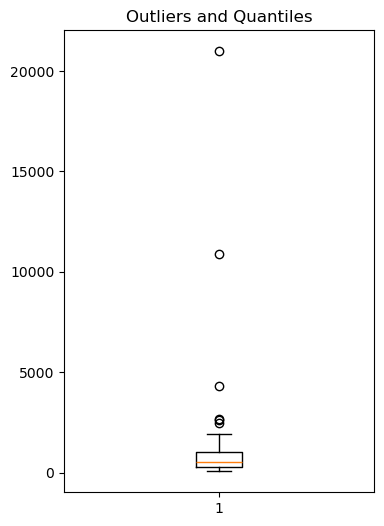

In [747]:
fig, ax1 = plt.subplots(figsize=(4, 6))

ax1.boxplot(city_data["Population Density"].dropna()) 

ax1.set_title("Outliers and Quantiles") 

plt.show()

In [748]:
q1 = city_data['Population Density'].quantile(0.25)
q3 = city_data['Population Density'].quantile(0.75)
inter_quartile_range = q3 - q1

outliers = city_data[(city_data['Population Density'] < q1 - 1.5*inter_quartile_range) | 
              (city_data['Population Density'] > q3 + 1.5*inter_quartile_range)]

outliers[['City', 'Population Density']]

,City,Population Density
32,Tallinn,2469.0
35,Paris,20983.0
36,Lyon,10909.0
37,Toulouse,4300.0
54,Naples,2615.0
61,The Hague,2646.0


<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Population Density</code> has 6 outliers:
  <ul>
    <li><code>Tallinn</code></li>
    <li><code>Paris</code></li>
    <li><code>Lyon</code></li>
    <li><code>Toulouse</code></li>
    <li><code>Naples</code></li>
    <li><code>The Hague</code></li>
  </ul>
</div>

<h4>Skewness Analysis:</h4>

In [749]:
mean = city_data['Population Density'].mean()
median = city_data['Population Density'].median()

print(f'The mean is {mean}, while the median is {median}.')

The mean is 1131.4698795180723, while the median is 548.0.


<p>Let's plot a histogram to visualise the skewness:</p>

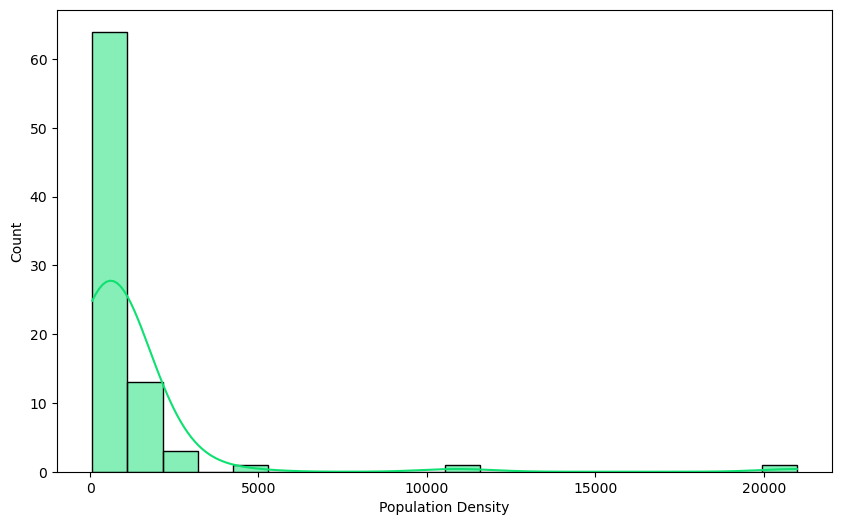

In [750]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data= city_data,
    x='Population Density',
    bins=20,
    kde=True,  
    color='#0EE071'
)

plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Population Density</code> is right skewed:
  <ul>
    <li>The mean is much bigger than the median.</li>
    <li>The histogram has a tail to the right.</li>
  </ul>
</div>

<h4>Imputation of Missing Value</h4>

<p>As there is only one missing value, and not considering dropping the city of Valencia from our dataset, let's explore imputation options:</p>
<ul>
    <li><b>Mean</b>: Sensitive to outliers and skewness. As we saw, this variable has 6 outliers from 83 values and is right skewed.</li>
    <li><b>Median</b>: Robust to outliers and skewness, and farily simple to implemment.</li>
    <li><b>Mode</b>: More used with categorical data.</li>
    <li><b>KNN</b>: Robust approach, but for this case might be overengeneering given that there is only 1 value missing in the respective column(<code>Population Density</code>).</li>
</ul>

<p><b>Note</b>: We're doing an imputation for wider (and possibly multivariate) further statistical studies. But for future considerations of this variable and city, we should be aware of the imputation. We could add documentation in the dataset on, for example, a <code>Notes</code> column or create a imputation flag column (binary value), but this will create more confusion in the analysis of the dataset, and for the purpose of this project, we will only leave this note on this notebook.</p>
<p>Therefore, we will go ahead with the Median Imputation:</p>

In [751]:
median = city_data['Population Density'].median()
city_data['Population Density'] = city_data['Population Density'].fillna(median)

Check:

In [752]:
city_data.iloc[29,:]

Population Density                               548.0
Population                                     1748142
Working Age Population                       1162828.0
Youth Dependency Ratio                            22.6
Unemployment Rate                                 13.7
GDP per Capita                                 33570.0
Days of very strong heat stress                      5
Main Spoken Languages                Spanish;Valencian
Average Monthly Salary                            2400
Avgerage Rent Price                               1190
Average Cost of Living                            1300
Average Price Groceries                            NaN
Last Data Update                   2023-06-04 00:00:00
City                                          Valencia
Country                                          Spain
Name: 29, dtype: object

<h4>Data Type Evaluation:</h4>

<p>As this variable is a <code>float64</code>, we don't think there is no need to change it to a <code>float32</code>.</p>
<p>Changing it would save some memory, but would mean losing some detail in the decimals, as the <code>Population Density</code> is a ratio (Population/Area).</p>

<h3><code>Population</code></h3>
<p style = "font-size : 15px;"><b>Number of inhabitants.</b></p>
<p><b>Data Type:</b> int64</p>
<p><b>Missing Values:</b> 0</p>

<h4>Search for outliers:</h4>

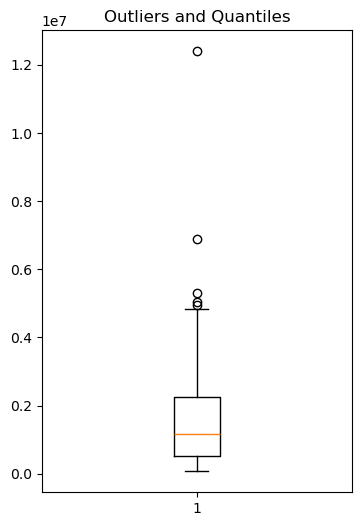

In [753]:
fig, ax1 = plt.subplots(figsize=(4, 6))

ax1.boxplot(city_data["Population"]) 

ax1.set_title("Outliers and Quantiles") 

plt.show()

In [754]:
q1 = city_data['Population'].quantile(0.25)
q3 = city_data['Population'].quantile(0.75)
inter_quartile_range = q3 - q1

outliers = city_data[(city_data['Population'] < q1 - 1.5*inter_quartile_range) | 
              (city_data['Population'] > q3 + 1.5*inter_quartile_range)]

outliers[['City', 'Population']]

,City,Population
15,Berlin,5303922
27,Madrid,6882461
28,Barcelona,5034925
38,London,12396541
53,Milan,4965808


<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Population</code> has 5 outliers, these are, by far, the biggest cities in Europe:
  <ul>
    <li><code>Berlin</code></li>
    <li><code>Madrid</code></li>
    <li><code>Barcelona</code></li>
    <li><code>London</code></li>
    <li><code>Milan</code></li>
  </ul>
</div>

<h4>Skewness Analysis:</h4>

In [755]:
mean = city_data['Population'].mean()
median = city_data['Population'].median()

print(f'The mean is {mean}, while the median is {median}.')

The mean is 1722652.9166666667, while the median is 1178397.0.


<p>Let's plot a histogram to visualise the skewness. Before, we should take out the outliers for a better visualisation, avoiding the main cluster being squashed.</p>

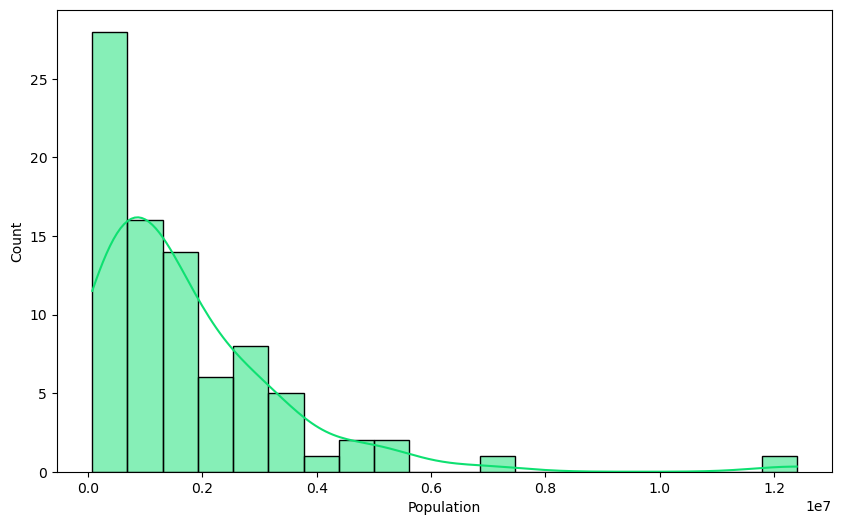

In [756]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data= city_data,
    x='Population',
    bins=20,
    kde=True,  
    color='#0EE071'
)

plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Population</code> is right skewed:
  <ul>
    <li>The mean is bigger than the median.</li>
    <li>The histogram has a tail to the right.</li>
  </ul>
</div>

<h4>Data Type Evaluation:</h4>

<p>As this variable is an <code>int64</code> and it is a count of integers, there is room to fit until aorun 9 quintillion.</p>
<p>Changing it to <code>int32</code> would save some memory, while keeping room to go until 2 billion(as the city with the most population is  <code>London</code> and has 1.2 million inhabitants).</p>

In [757]:
city_data['Population'] = city_data['Population'].astype('int32')

Check:

In [758]:
city_data['Population'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 84 entries, 0 to 83
Series name: Population
Non-Null Count  Dtype
--------------  -----
84 non-null     int32
dtypes: int32(1)
memory usage: 468.0 bytes


<h3><code>Working Age Population </code></h3>
<p style = "font-size : 15px;"><b>Number of people between 15 and 64 years of age.</b></p>
<p><b>Data Type:</b> float64</p>
<p><b>Missing Values:</b> 1</p>

In [759]:
city_data['Working Age Population '].describe()

count    8.300000e+01
mean     1.137206e+06
std      1.218990e+06
min      4.635900e+04
25%      3.529005e+05
50%      7.337940e+05
75%      1.490012e+06
max      8.274794e+06
Name: Working Age Population , dtype: float64

<h4>Name of Variable</h4>

<p>The name of this variable in the dataset is 'Working Age Population ', with the space after the word 'Population'.</p>
<p>This is not ideal as Pandas is sensible to spaces in the varibale names, and that space is not logical. Therefore let's change it:</p>

In [760]:
city_data = city_data.rename(columns={
    'Working Age Population ': 'Working Age Population'
})

Check (by calling the <code>.describe()</code> method on the new name):

In [761]:
city_data['Working Age Population'].describe()

count    8.300000e+01
mean     1.137206e+06
std      1.218990e+06
min      4.635900e+04
25%      3.529005e+05
50%      7.337940e+05
75%      1.490012e+06
max      8.274794e+06
Name: Working Age Population, dtype: float64

<h4>Search for the missing value:</h4>

In [762]:
city_data[city_data['Working Age Population'].isna()]

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country
23,1295.0,1554077,NaN,21.4,3.3,71238.0,3,NaN,3200,1100,2050,NaN,2024-01-15 00:00:00,Dusseldorf,Germany


<p style = "border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
Concluding that <code>Dusseldorf</code> is the city that doesn't have a known value for <code>Working Age Population</code>.</p>

<h4>Search for outliers:</h4>

<p>Let's make a visualization for the outliers of the variable <code>Working Age Population</code>.</p>

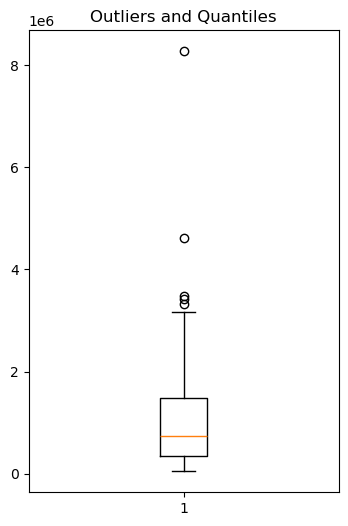

In [763]:
fig, ax1 = plt.subplots(figsize=(4, 6))

ax1.boxplot(city_data["Working Age Population"].dropna()) 

ax1.set_title("Outliers and Quantiles") 

plt.show()

In [764]:
q1 = city_data['Working Age Population'].quantile(0.25)
q3 = city_data['Working Age Population'].quantile(0.75)
inter_quartile_range = q3 - q1

outliers = city_data[(city_data['Working Age Population'] < q1 - 1.5*inter_quartile_range) | 
              (city_data['Working Age Population'] > q3 + 1.5*inter_quartile_range)]

outliers[['City', 'Working Age Population']]

,City,Working Age Population
15,Berlin,3481212.0
27,Madrid,4617753.0
28,Barcelona,3331345.0
38,London,8274794.0
82,Ankara,3417691.0


<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Working Age Population</code> has 5 outliers:
  <ul>
    <li><code>Berlin</code></li>
    <li><code>Madrid</code></li>
    <li><code>Barcelona</code></li>
    <li><code>London</code></li>
    <li><code>Ankara</code></li>
  </ul>
</div>

<h4>Skewness Analysis:</h4>

In [765]:
mean = city_data['Working Age Population'].mean()
median = city_data['Working Age Population'].median()

print(f'The mean is {mean}, while the median is {median}.')

The mean is 1137206.4819277108, while the median is 733794.0.


<p>Let's plot a histogram to visualise the skewness:</p>

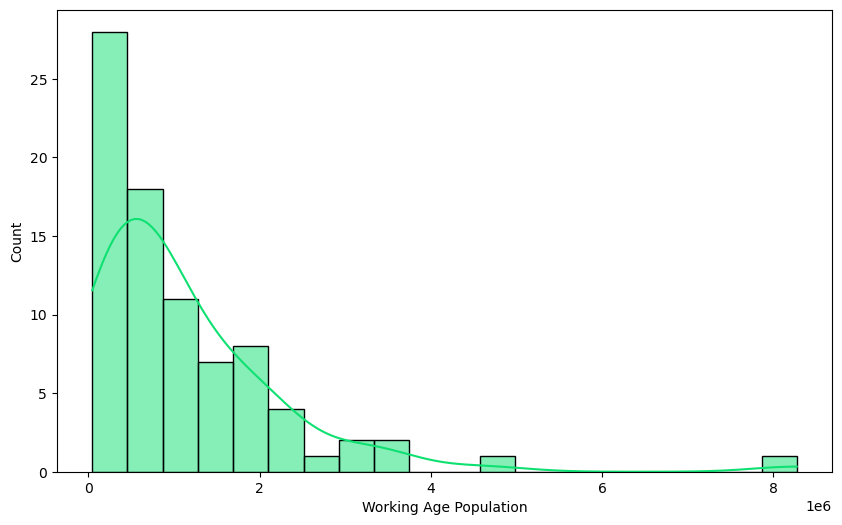

In [766]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data= city_data,
    x='Working Age Population',
    bins=20,
    kde=True,  
    color='#0EE071'
)

plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Working Age Population</code> is right skewed:
  <ul>
    <li>The mean is bigger than the median.</li>
    <li>The histogram has a tail to the right.</li>
  </ul>
</div>

<h4>Imputation of Missing Value</h4>

<p>As there is only one missing value, and not considering dropping the city of Dusselford from our dataset, let's explore imputation options:</p>
<ul>
    <li><b>Mean</b>: Sensitive to outliers and skewness. As we saw, this variable has 5 outliers from 83 values and is right skewed.</li>
    <li><b>Median</b>: Robust to outliers and skewness, and farily simple to implemment.</li>
    <li><b>Mode</b>: More used with categorical data.</li>
    <li><b>KNN</b>: Robust approach, but for this case might be overengeneering given that there is only 1 value missing both in the respective column (<code>Working Age Population</code>).</li>
</ul>

<p><b>Note</b>: We're doing an imputation for wider (and possibly multivariate) further statistical studies. But for future considerations of this variable and city, we should be aware of the imputation. We could add documentation in the dataset on, for example, a <code>Notes</code> column or create a imputation flag column (binary value), but this will create more confusion in the analysis of the dataset, and for the purpose of this project, we will only leave this note on this notebook.</p>
<p>Therefore, we will go ahead with the Median Imputation:</p>

In [767]:
median = city_data['Working Age Population'].median()
city_data['Working Age Population'] = city_data['Working Age Population'].fillna(median)

Check:

In [768]:
city_data.iloc[23,:]

Population Density                              1295.0
Population                                     1554077
Working Age Population                        733794.0
Youth Dependency Ratio                            21.4
Unemployment Rate                                  3.3
GDP per Capita                                 71238.0
Days of very strong heat stress                      3
Main Spoken Languages                              NaN
Average Monthly Salary                            3200
Avgerage Rent Price                               1100
Average Cost of Living                            2050
Average Price Groceries                            NaN
Last Data Update                   2024-01-15 00:00:00
City                                        Dusseldorf
Country                                        Germany
Name: 23, dtype: object

<h4>Data Type Evaluation:</h4>

<p>As this variable is currently a <code>float64</code> but it is a count of integers, there is no need to account for floats.</p>
<p>Changing it to <code>int32</code> would save memory, while keeping room to go until 2 billion integers (as the city with the most <code>Working Age Population</code> is <code>London</code> and has 8 million people in the working age population).</p>

In [769]:
city_data['Working Age Population'] = city_data['Working Age Population'].astype('int32')

Check:

In [770]:
city_data['Working Age Population'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 84 entries, 0 to 83
Series name: Working Age Population
Non-Null Count  Dtype
--------------  -----
84 non-null     int32
dtypes: int32(1)
memory usage: 468.0 bytes


<h3><code>Youth Dependency Ratio</code></h3>
<p style = "font-size : 15px;"><b>Ratio of -15 population over 15-64 population.</b></p>
<p><b>Data Type:</b> float64</p>
<p><b>Missing Values:</b> 0</p>

In [771]:
city_data['Youth Dependency Ratio'].describe()

count    84.000000
mean     24.137262
std       3.290351
min      19.300000
25%      21.475000
50%      23.150000
75%      26.050000
max      37.800000
Name: Youth Dependency Ratio, dtype: float64

<h4>Search for outliers:</h4>

<p>Let's make a visualization for the outliers of the variable <code>Youth Dependency Ratio</code>.</p>

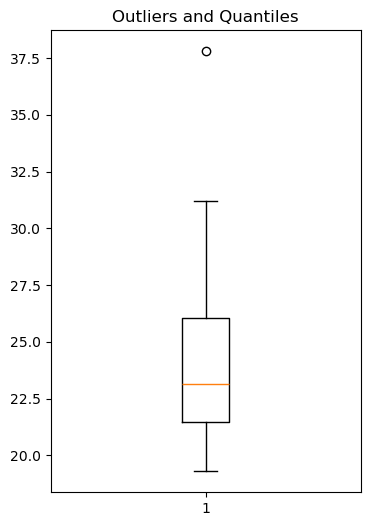

In [772]:
fig, ax1 = plt.subplots(figsize=(4, 6))

ax1.boxplot(city_data["Youth Dependency Ratio"])

ax1.set_title("Outliers and Quantiles") 

plt.show()

In [773]:
q1 = city_data['Youth Dependency Ratio'].quantile(0.25)
q3 = city_data['Youth Dependency Ratio'].quantile(0.75)
inter_quartile_range = q3 - q1

outliers = city_data[(city_data['Youth Dependency Ratio'] < q1 - 1.5*inter_quartile_range) | 
              (city_data['Youth Dependency Ratio'] > q3 + 1.5*inter_quartile_range)]

outliers[['City', 'Youth Dependency Ratio']]

,City,Youth Dependency Ratio
83,Adana,37.8


<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Working Age Population</code> has only 1 outlier:
  <ul>
    <li><code>Adana</code></li>
  </ul>
</div>

<h4>Skewness Analysis:</h4>

In [774]:
mean = city_data['Youth Dependency Ratio'].mean()
median = city_data['Youth Dependency Ratio'].median()

print(f'The mean is {mean}, while the median is {median}.')

The mean is 24.137261904761903, while the median is 23.15.


<p>Let's plot a histogram to visualise the skewness:</p>

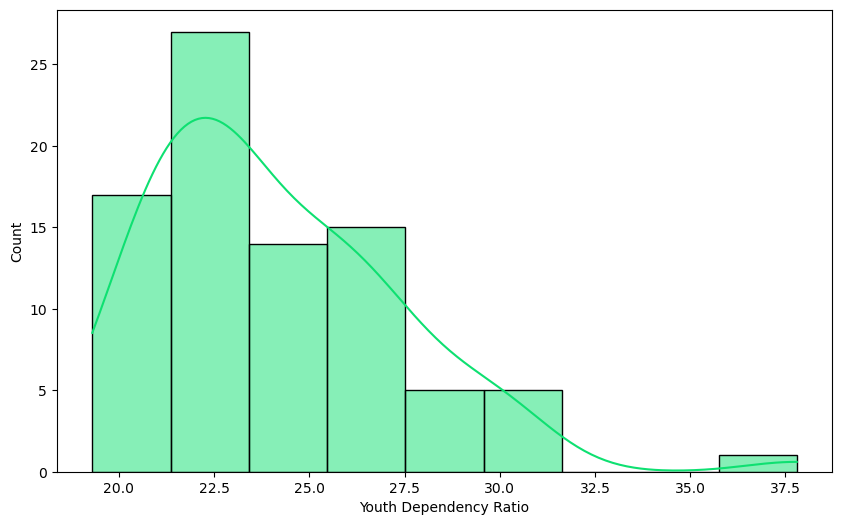

In [775]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data= city_data,
    x='Youth Dependency Ratio',
    kde=True,  
    color='#0EE071'
)

plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Youth Dependency Ratio</code> is right skewed:
  <ul>
    <li>The mean is bigger than the median.</li>
    <li>The histogram has a tail to the right.</li>
  </ul>
</div>

<h4>Data Type Evaluation:</h4>

<p>As this variable is a <code>float64</code>, we don't think there is no need to change it to a <code>float32</code>.</p>
<p>Changing it would save some memory, but would possibly mean losing some detail in the decimals, as the <code>Youth Dependency Ratio</code> is a ratio.</p>

<h3><code>Unemployment Rate</code></h3>
<p style = "font-size : 15px;"><b>Unemployed Population over Working Age Population.</b></p>
<p><b>Data Type:</b> float64</p>
<p><b>Missing Values:</b> 1</p>

In [776]:
city_data['Unemployment Rate'].describe()

count    83.000000
mean      6.557831
std       4.438197
min       1.400000
25%       3.700000
50%       5.300000
75%       7.800000
max      23.000000
Name: Unemployment Rate, dtype: float64

<h4>Search for the missing value:</h4>

In [777]:
city_data[city_data['Unemployment Rate'].isna()]

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country
4,552.0,645813,417832,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17 00:00:00,Gent,Belgium


<p style = "border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
Concluding that <code>Gent</code> is the city that doesn't have a known value for <code>Unemployment Rate</code>.</p>

<h4>Search for outliers:</h4>

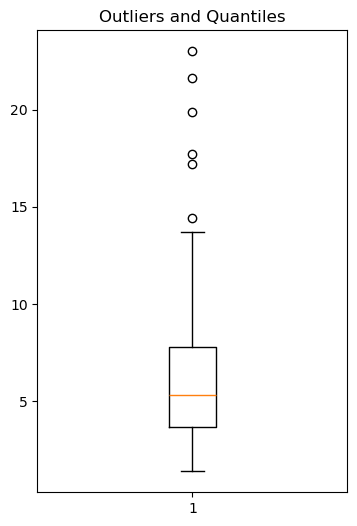

In [778]:
fig, ax1 = plt.subplots(figsize=(4, 6))

ax1.boxplot(city_data["Unemployment Rate"].dropna()) 

ax1.set_title("Outliers and Quantiles") 

plt.show()

In [779]:
q1 = city_data['Unemployment Rate'].quantile(0.25)
q3 = city_data['Unemployment Rate'].quantile(0.75)
inter_quartile_range = q3 - q1

outliers = city_data[(city_data['Unemployment Rate'] < q1 - 1.5*inter_quartile_range) | 
              (city_data['Unemployment Rate'] > q3 + 1.5*inter_quartile_range)]

outliers[['City', 'Unemployment Rate']]

,City,Unemployment Rate
30,Seville,21.6
31,Malaga,17.7
43,Athens,17.2
44,Thessaloniki,19.9
54,Naples,23.0
82,Ankara,14.4


<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Unemployment Rate</code> has 6 outliers:
  <ul>
    <li><code>Seville</code></li>
    <li><code>Malaga</code></li>
    <li><code>Athens</code></li>
    <li><code>Thessaloniki</code></li>
    <li><code>Naples</code></li>
    <li><code>Ankara</code></li>
  </ul>
</div>

<h4>Skewness Analysis:</h4>

In [780]:
mean = city_data['Unemployment Rate'].mean()
median = city_data['Unemployment Rate'].median()

print(f'The mean is {mean}, while the median is {median}.')

The mean is 6.557831325301206, while the median is 5.3.


<p>Let's plot a histogram to visualise the skewness:</p>

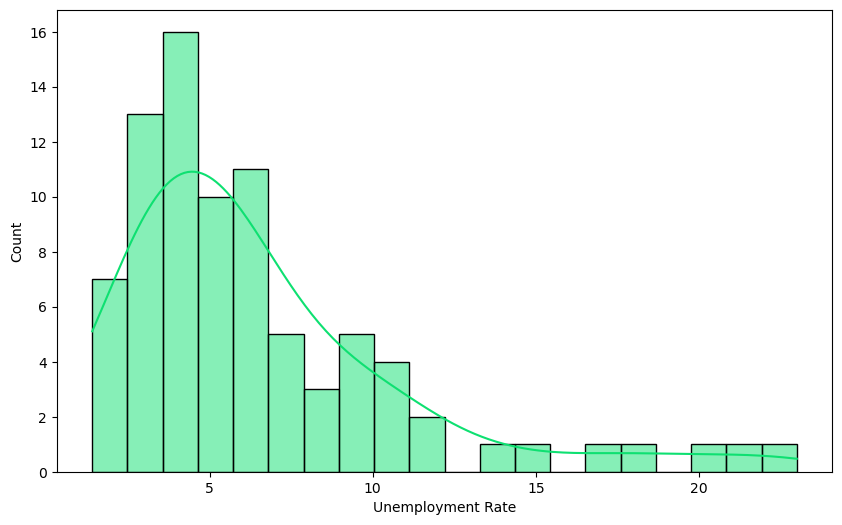

In [781]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data= city_data,
    x='Unemployment Rate',
    bins=20,
    kde=True,  
    color='#0EE071'
)

plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Unemployment Rate</code> is right skewed:
  <ul>
    <li>The mean is bigger than the median.</li>
    <li>The histogram has a tail to the right.</li>
  </ul>
</div>

<h4>Imputation of Missing Value</h4>

<p>As there is only one missing value, and not considering dropping the city of Gent from our dataset, let's explore imputation options:</p>
<ul>
    <li><b>Mean</b>: Sensitive to outliers and skewness. As we saw, this variable has 6 outliers from 83 values and is right skewed.</li>
    <li><b>Median</b>: Robust to outliers and skewness, and farily simple to implemment.</li>
    <li><b>Mode</b>: More used with categorical data.</li>
    <li><b>KNN</b>: Robust approach, but for this case might be overengeneering given that there is only 1 value missing in the respective column(<code>Unemployment Rate</code>).</li>
</ul>

<p><b>Note</b>: We're doing an imputation for wider (and possibly multivariate) further statistical studies. But for future considerations of this variable and city, we should be aware of the imputation. We could add documentation in the dataset on, for example, a <code>Notes</code> column or create a imputation flag column (binary value), but this will create more confusion in the analysis of the dataset, and for the purpose of this project, we will only leave this note on this notebook.</p>
<p>Therefore, we will go ahead with the Median Imputation:</p>

In [782]:
median = city_data['Unemployment Rate'].median()
city_data['Unemployment Rate'] = city_data['Unemployment Rate'].fillna(median)

Check:

In [783]:
city_data.iloc[4,:]

Population Density                               552.0
Population                                      645813
Working Age Population                          417832
Youth Dependency Ratio                            24.8
Unemployment Rate                                  5.3
GDP per Capita                                 53311.0
Days of very strong heat stress                      2
Main Spoken Languages                    Dutch, French
Average Monthly Salary                            2400
Avgerage Rent Price                                827
Average Cost of Living                            1200
Average Price Groceries                          120.0
Last Data Update                   2023-07-17 00:00:00
City                                              Gent
Country                                        Belgium
Name: 4, dtype: object

<h4>Data Type Evaluation:</h4>

<p>As this variable is a <code>float64</code>, we don't think there is no need to change it to a <code>float32</code>.</p>
<p>Changing it would save some memory, but would possibly mean losing some detail in the decimals, as the <code>Umemployment Rate</code> is a ratio.</p>

<h3><code>GDP per Capita</code></h3>
<p style = "font-size : 15px;"><b>GDP per capita in USD.</b></p>
<p><b>Data Type:</b> float64</p>
<p><b>Missing Values:</b> 1</p>

In [784]:
city_data['GDP per Capita'].describe()

count        83.000000
mean      52102.782169
std       21582.821631
min       10089.920000
25%       38790.000000
50%       49588.000000
75%       63311.500000
max      146094.000000
Name: GDP per Capita, dtype: float64

<h4>Search for the missing value:</h4>

In [785]:
city_data[city_data['GDP per Capita'].isna()]

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country
12,190.0,262238,173906,23.06,11.2,NaN,0,"Greek, English, Russian",2500,1400,2300,NaN,2023-08-14 00:00:00,Lemesos,Cyprus


<p style = "border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
Concluding that <code>Lemesos</code> is the city that doesn't have a known value for <code>GDP per Capita</code>.</p>

<h4>Search for outliers:</h4>

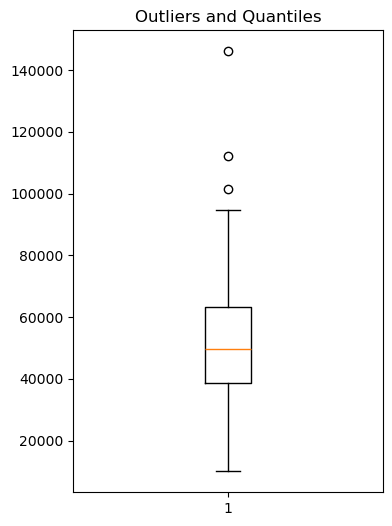

In [786]:
fig, ax1 = plt.subplots(figsize=(4, 6))

ax1.boxplot(city_data["GDP per Capita"].dropna()) 

ax1.set_title("Outliers and Quantiles") 

plt.show()

In [787]:
q1 = city_data['GDP per Capita'].quantile(0.25)
q3 = city_data['GDP per Capita'].quantile(0.75)
inter_quartile_range = q3 - q1

outliers = city_data[(city_data['GDP per Capita'] < q1 - 1.5*inter_quartile_range) | 
              (city_data['GDP per Capita'] > q3 + 1.5*inter_quartile_range)]

outliers[['City', 'GDP per Capita']]

,City,GDP per Capita
50,Dublin,101483.0
51,Cork,146094.0
58,Luxembourg,112143.0


<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>GDP per Capita</code> has 3 outliers:
  <ul>
    <li><code>Dublin</code></li>
    <li><code>Cork</code></li>
    <li><code>Luxembourg</code></li>
  </ul>
</div>

<h4>Skewness Analysis:</h4>

In [788]:
mean = city_data['GDP per Capita'].mean()
median = city_data['GDP per Capita'].median()

print(f'The mean is {mean}, while the median is {median}.')

The mean is 52102.7821686747, while the median is 49588.0.


<p>Let's plot a histogram to visualise the skewness:</p>

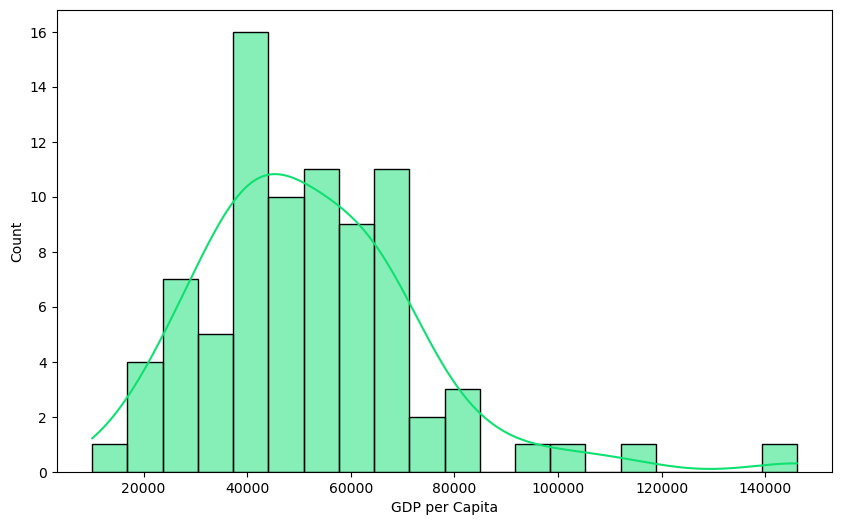

In [789]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data= city_data,
    x='GDP per Capita',
    bins=20,
    kde=True,  
    color='#0EE071'
)

plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>GDP per Capita</code> is right skewed:
  <ul>
    <li>The mean is bigger than the median.</li>
    <li>The histogram has a bigger tail to the right.</li>
    <li>There are only positive outliers (to the right).</li>
  </ul>
</div>

<h4>Imputation of Missing Value</h4>

<p>As there is only one missing value, and not considering dropping the city of Lemesos from our dataset, let's explore imputation options:</p>
<ul>
    <li><b>Mean</b>: Sensitive to outliers and skewness. As we saw, this variable has 3 outliers from 83 values and is right skewed.</li>
    <li><b>Median</b>: Robust to outliers and skewness, and farily simple to implemment.</li>
    <li><b>Mode</b>: More used with categorical data.</li>
    <li><b>KNN</b>: Robust approach, but for this case might be overengeneering given that there is only 1 value missing n the respective column(<code>GDP per Capita</code>).</li>
</ul>

<p><b>Note</b>: We're doing an imputation for wider (and possibly multivariate) further statistical studies. But for future considerations of this variable and city, we should be aware of the imputation. We could add documentation in the dataset on, for example, a <code>Notes</code> column or create a imputation flag column (binary value), but this will create more confusion in the analysis of the dataset, and for the purpose of this project, we will only leave this note on this notebook.</p>
<p>Therefore, we will go ahead with the Median Imputation:</p>

In [790]:
median = city_data['GDP per Capita'].median()
city_data['GDP per Capita'] = city_data['GDP per Capita'].fillna(median)

Check:

In [791]:
city_data.iloc[12,:]

Population Density                                   190.0
Population                                          262238
Working Age Population                              173906
Youth Dependency Ratio                               23.06
Unemployment Rate                                     11.2
GDP per Capita                                     49588.0
Days of very strong heat stress                          0
Main Spoken Languages              Greek, English, Russian
Average Monthly Salary                                2500
Avgerage Rent Price                                   1400
Average Cost of Living                                2300
Average Price Groceries                                NaN
Last Data Update                       2023-08-14 00:00:00
City                                               Lemesos
Country                                             Cyprus
Name: 12, dtype: object

<h4>Data Type Evaluation:</h4>

<p>As this variable is a <code>float64</code>, we don't think there is no need to change it to a <code>float32</code>.</p>
<p>Changing it would save some memory, but would mean losing some detail in the decimals, as the <code>GDP per Capita</code> is a ratio (GPD/Population).</p>

<h3><code>Days of very strong heat stress</code></h3>
<p style = "font-size : 15px;"><b>Days of very strong heat stress (UTCI > 38°C).</b></p>
<p><b>Data Type:</b> int64</p>
<p><b>Missing Values:</b> 0</p>

In [792]:
city_data['Days of very strong heat stress'].describe()

count    84.000000
mean      4.416667
std      10.146171
min       0.000000
25%       0.000000
50%       1.000000
75%       3.000000
max      59.000000
Name: Days of very strong heat stress, dtype: float64

<h4>Search for outliers:</h4>

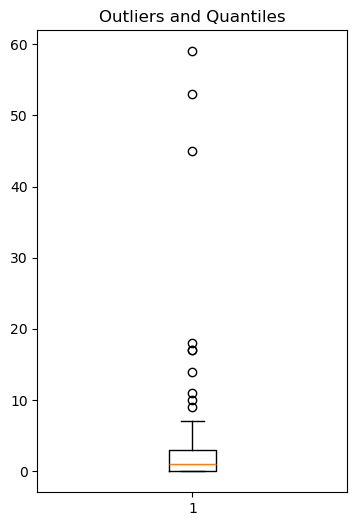

In [793]:
fig, ax1 = plt.subplots(figsize=(4, 6))

ax1.boxplot(city_data["Days of very strong heat stress"].dropna()) 

ax1.set_title("Outliers and Quantiles") 

plt.show()

In [794]:
q1 = city_data['Days of very strong heat stress'].quantile(0.25)
q3 = city_data['Days of very strong heat stress'].quantile(0.75)
inter_quartile_range = q3 - q1

outliers = city_data[(city_data['Days of very strong heat stress'] < q1 - 1.5*inter_quartile_range) | 
              (city_data['Days of very strong heat stress'] > q3 + 1.5*inter_quartile_range)]

outliers[['City', 'Days of very strong heat stress']]

,City,Days of very strong heat stress
11,Lefkosia,45
27,Madrid,18
30,Seville,53
36,Lyon,11
37,Toulouse,14
43,Athens,17
44,Thessaloniki,10
53,Milan,17
56,Florence,9
83,Adana,59


<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Days of very strong heat stress</code> has 10 outliers:
  <ul>
    <li><code>Lefkosia</code></li>
    <li><code>Madrid</code></li>
    <li><code>Seville</code></li>
    <li><code>Lyon</code></li>
    <li><code>Toulouse</code></li>
    <li><code>Athens</code></li>
    <li><code>Thessaloniki</code></li>
    <li><code>Milan</code></li>
    <li><code>Florence</code></li>
    <li><code>Adana</code></li>
  </ul>
</div>

<h4>Skewness Analysis:</h4>

In [795]:
mean = city_data['Days of very strong heat stress'].mean()
median = city_data['Days of very strong heat stress'].median()

print(f'The mean is {mean}, while the median is {median}.')

The mean is 4.416666666666667, while the median is 1.0.


<p>Let's plot a histogram to visualise the skewness:</p>

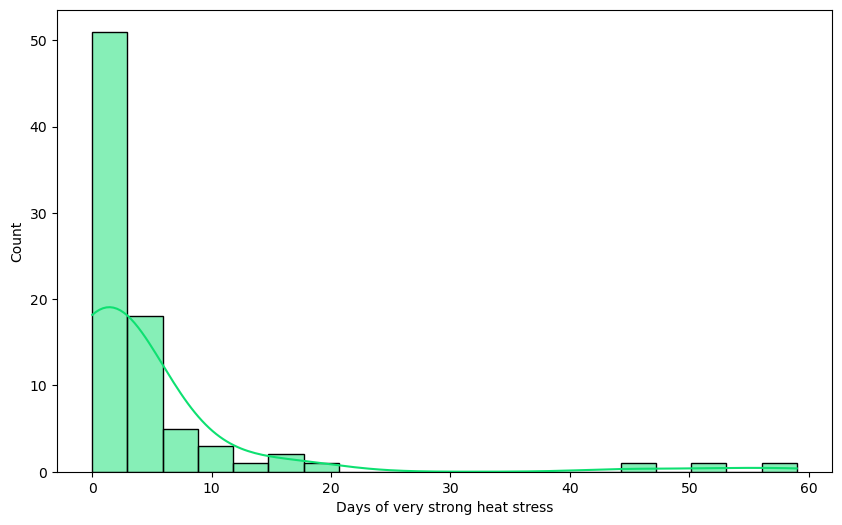

In [796]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data= city_data,
    x='Days of very strong heat stress',
    bins=20,
    kde=True,  
    color='#0EE071'
)

plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Days of very strong heat stress</code> is right skewed:
  <ul>
    <li>The mean is much bigger than the median.</li>
    <li>The histogram has a long tail to the right.</li>
  </ul>
</div>

<h4>Data Type Evaluation:</h4>

<p>As this variable is an <code>int64</code> and it is a count of integers, there is room to fit until aorun 9 quintillion.</p>
<p>Changing it to <code>int16</code> would save some memory, while keeping room to go until 32 thousands (as the city with the most days of very strong heat stress is <code>Adana</code> and has 59 days).</p>

In [797]:
city_data['Days of very strong heat stress'] = city_data['Days of very strong heat stress'].astype('int16')

Check:

In [798]:
city_data['Days of very strong heat stress'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 84 entries, 0 to 83
Series name: Days of very strong heat stress
Non-Null Count  Dtype
--------------  -----
84 non-null     int16
dtypes: int16(1)
memory usage: 300.0 bytes


<h3><code>Main Spoken Languages</code></h3>
<p style = "font-size : 15px;"><b>List of languages spoked in each city.</b></p>
<p><b>Data Type:</b> object/string</p>
<p><b>Missing Values:</b> 1</p>

<h4>Search for missing value, and deal with it:</h4>
<p>Once we locate the missing value, we know that, as far as this dataset is concerned, we cannot find the main spoken languages of that city.</p>
<p>And thus we will put a string 'Unknown' in that missing value. This will help us in further processing of this variable.</p>

In [799]:
city_data[city_data['Main Spoken Languages'].isna()]

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country
23,1295.0,1554077,733794,21.4,3.3,71238.0,3,NaN,3200,1100,2050,NaN,2024-01-15 00:00:00,Dusseldorf,Germany


<p style = "border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
Concluding that <code>Dusseldorf</code> is the city that doesn't have a known value for <code>Main Spoken Languages</code>.</p>

In [800]:
city_data['Main Spoken Languages'] = city_data['Main Spoken Languages'].fillna('Unknown')

Check:

In [801]:
city_data.iloc[23,:]

Population Density                              1295.0
Population                                     1554077
Working Age Population                          733794
Youth Dependency Ratio                            21.4
Unemployment Rate                                  3.3
GDP per Capita                                 71238.0
Days of very strong heat stress                      3
Main Spoken Languages                          Unknown
Average Monthly Salary                            3200
Avgerage Rent Price                               1100
Average Cost of Living                            2050
Average Price Groceries                            NaN
Last Data Update                   2024-01-15 00:00:00
City                                        Dusseldorf
Country                                        Germany
Name: 23, dtype: object

<h4>Transforming Multi-Label Categorical Data:</h4>
<p>As it stands, it will be very difficult to do any analysis on this variable. If a city has got more than 1 main spoken language, the different languages are all in the same string, splitted by ', ', ';' or ' '.</p>
<p>That's why we will standardise the separators and then create a series of new columns, each column with the dummy binary variable corresponding to one language. If in one given city the language corresponding to a column is one of the main spoken languages, the column will have a '1', if not, it will have a '0'.</p>

<p>Standardise the splits:</p>

In [802]:
city_data['Main Spoken Languages'] = city_data['Main Spoken Languages'].str.replace(';', ',', regex=False)
city_data['Main Spoken Languages'] = city_data['Main Spoken Languages'].str.replace(', ', ',', regex=False)

In [803]:
city_data['Main Spoken Languages'] = city_data['Main Spoken Languages'].str.replace(' ', ',', regex=False)

<p>Split the strings into lists:</p>

In [804]:
language_dv = city_data['Main Spoken Languages'].str.split(',', expand=False)

In [805]:
language_dv

0     [German, English, Turkish, Serbian]
1                                [German]
2        [French, Dutch, Arabic, English]
3                 [Dutch, French, Arabic]
4                         [Dutch, French]
                     ...                 
79                     [Swedish, English]
80                     [Swedish, English]
81                     [Swedish, English]
82                              [Turkish]
83                              [Turkish]
Name: Main Spoken Languages, Length: 84, dtype: object

<p>Converting the list into one language per row:</p>

In [806]:
language_dv = language_dv.explode()
language_dv # The old elements of the list are now splitted, each city still represents 1 index that repeats if the city has more than 1 main spoken languages

0      German
0     English
0     Turkish
0     Serbian
1      German
       ...   
80    English
81    Swedish
81    English
82    Turkish
83    Turkish
Name: Main Spoken Languages, Length: 162, dtype: object

<p>Creating a dataset with the dummy variables for each language</p>

In [807]:
language_dv = pd.get_dummies(language_dv)
language_dv

,,Arabic,Bengali,Bulgarian,Catalan,Croatian,Czech,Danish,Dutch,English,Estonian,Finnish,French,Gaelic,German,Greek,Hungarian,Irish,Italian,Latvian,Luxembourgish,Maltese,Norwegian,Polish,Portuguese,Romanian,Russian,Scots,Serbian,Slovak,Slovene,Spanish,Swedish,Turkish,Unknown,Urdu,Valencian
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
81,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
81,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
82,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [808]:
language_dv = language_dv.iloc[:,1:] #just to get rid of the all 'False' 1st column

<p>Merging the equal indexes into 1 single row, and turning the 'True'/'False' into '1'/'0' for simplicity:</p>

In [809]:
language_dv = language_dv.groupby(language_dv.index).sum()
language_dv = language_dv.astype('int8')
language_dv

,Arabic,Bengali,Bulgarian,Catalan,Croatian,Czech,Danish,Dutch,English,Estonian,Finnish,French,Gaelic,German,Greek,Hungarian,Irish,Italian,Latvian,Luxembourgish,Maltese,Norwegian,Polish,Portuguese,Romanian,Russian,Scots,Serbian,Slovak,Slovene,Spanish,Swedish,Turkish,Unknown,Urdu,Valencian
0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
80,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
81,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


<p>Now let's merge this dataset into the <code>city_data</code> dataset and drop the old <code>Main Spoken Languages</code> variable.</p>

In [810]:
city_data = city_data.merge(language_dv, left_index=True, right_index=True, how='left')
city_data = city_data.drop(columns=['Main Spoken Languages'])
city_data

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country,Arabic,Bengali,Bulgarian,Catalan,Croatian,Czech,Danish,Dutch,English,Estonian,Finnish,French,Gaelic,German,Greek,Hungarian,Irish,Italian,Latvian,Luxembourgish,Maltese,Norwegian,Polish,Portuguese,Romanian,Russian,Scots,Serbian,Slovak,Slovene,Spanish,Swedish,Turkish,Unknown,Urdu,Valencian
0,310.0,2983513,2018818,20.1,10.2,55770.0,3,2500,1050,2061,340.0,2024-06-15 00:00:00,Vienna,Austria,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1,243.0,375489,250472,20.3,3.0,66689.0,0,3200,1100,2186,NaN,2023-11-03 00:00:00,Salzburg,Austria,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,681.0,3284548,2137425,27.5,10.7,62500.0,3,3350,1200,1900,NaN,2023-04-22 00:00:00,Brussels,Belgium,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,928.0,1139663,723396,27.7,6.2,57595.0,3,2609,900,1953,NaN,2024-08-09 00:00:00,Antwerp,Belgium,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,552.0,645813,417832,24.8,5.3,53311.0,2,2400,827,1200,120.0,2023-07-17 00:00:00,Gent,Belgium,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,334.0,2344124,1534225,28.5,6.2,70950.0,0,2700,1400,2300,NaN,2024-09-11 00:00:00,Stockholm,Sweden,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
80,245.0,1037675,672152,28.2,6.3,49588.0,0,2500,1200,2100,NaN,2023-03-10 00:00:00,Gothenburg,Sweden,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
81,368.0,680335,436271,29.4,9.2,44387.0,0,2400,1100,2000,NaN,2024-07-07 00:00:00,Malmo,Sweden,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
82,1922.0,4843511,3417691,30.0,14.4,38916.0,3,900,450,900,309.0,2023-06-08 00:00:00,Ankara,Turkiye,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


<h3><code>Average Monthly Salary</code></h3>
<p style = "font-size : 15px;"><b>Estimated average monthly net salary in euros (€).</b></p>
<p><b>Data Type:</b> int64</p>
<p><b>Missing Values:</b> 0</p>

<h4>Search for outliers:</h4>

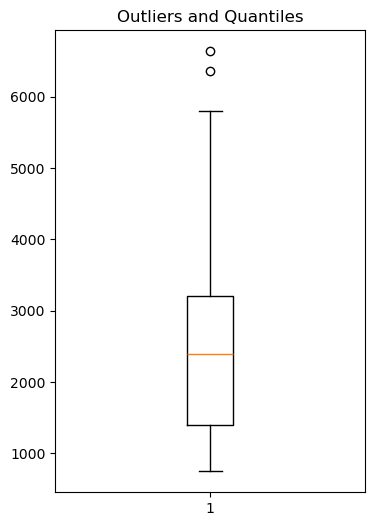

In [811]:
fig, ax1 = plt.subplots(figsize=(4, 6))

ax1.boxplot(city_data["Average Monthly Salary"]) 

ax1.set_title("Outliers and Quantiles") 

plt.show()

In [812]:
q1 = city_data['Average Monthly Salary'].quantile(0.25)
q3 = city_data['Average Monthly Salary'].quantile(0.75)
inter_quartile_range = q3 - q1

outliers = city_data[(city_data['Average Monthly Salary'] < q1 - 1.5*inter_quartile_range) | 
              (city_data['Average Monthly Salary'] > q3 + 1.5*inter_quartile_range)]

outliers[['City', 'Average Monthly Salary']]

,City,Average Monthly Salary
8,Zurich,6636
10,Basel,6366


<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Average Monthly Salary</code> has 2 outliers:
  <ul>
    <li><code>Zurich</code></li>
    <li><code>Basel</code></li>
  </ul>
</div>

<h4>Skewness Analysis:</h4>

In [813]:
mean = city_data['Average Monthly Salary'].mean()
median = city_data['Average Monthly Salary'].median()

print(f'The mean is {mean}, while the median is {median}.')

The mean is 2428.1666666666665, while the median is 2400.0.


<p>Let's plot a histogram to visualise the skewness:</p>

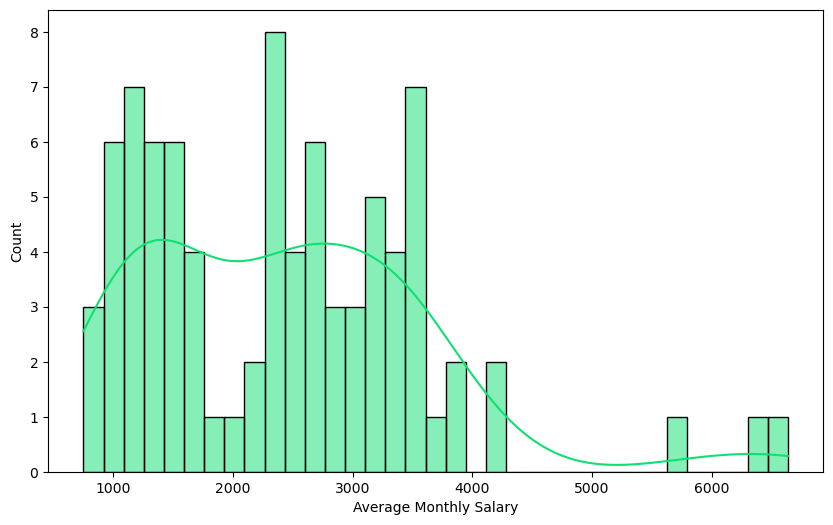

In [814]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data= city_data,
    x='Average Monthly Salary',
    bins=35,
    kde=True,  
    color='#0EE071'
)

plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Average Monthly Salary</code> is right skewed:
  <ul>
    <li>The mean is bigger than the median.</li>
    <li>The histogram has a tail to the right.</li>
      <li>Additionally, we can tell that besides the outliers, this varibale has 2 main clusters of cities. One being around 1000 and almost 2000, and the other around 2000 and 4000.</li>
  </ul>
</div>

<h4>Data Type Evaluation:</h4>

<p>As this variable is an <code>int64</code> by default, so there is room to fit until around 9 quintillion.</p>
<p>Changing it to <code>int16</code> would save some memory, while keeping room to go until 32 thousands (as the city with the most population is  <code>Zurich</code> and has no more than 7 thousand).</p>

In [815]:
city_data['Average Monthly Salary'] = city_data['Average Monthly Salary'].astype('int16')

Check:

In [816]:
city_data['Average Monthly Salary'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 84 entries, 0 to 83
Series name: Average Monthly Salary
Non-Null Count  Dtype
--------------  -----
84 non-null     int16
dtypes: int16(1)
memory usage: 300.0 bytes


<h3><code>Avgerage Rent Price</code></h3>
<p style = "font-size : 15px;"><b>Estimated average rent price for a 1 bedroom apartment at the city center, in euros (€).</b></p>
<p><b>Data Type:</b> int64</p>
<p><b>Missing Values:</b> 0</p>

<h4>Name of Variable</h4>

<p>The name of this variable in the dataset is 'Avgerage Rent Price', with a small mistake in the word 'Average'.</p>
<p>This is not ideal for readability. Therefore let's change it:</p>

In [817]:
city_data = city_data.rename(columns={
    'Avgerage Rent Price': 'Average Rent Price'
})

Check (by calling the <code>.describe()</code> method on the new name):

In [818]:
city_data['Average Rent Price'].describe()

count      84.000000
mean     1065.440476
std       503.951503
min       100.000000
25%       775.000000
50%      1050.000000
75%      1250.000000
max      3190.000000
Name: Average Rent Price, dtype: float64

<h4>Search for outliers:</h4>

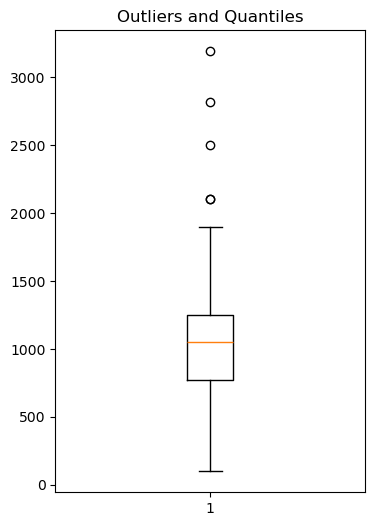

In [819]:
fig, ax1 = plt.subplots(figsize=(4, 6))

ax1.boxplot(city_data["Average Rent Price"]) 

ax1.set_title("Outliers and Quantiles") 

plt.show()

In [820]:
q1 = city_data['Average Rent Price'].quantile(0.25)
q3 = city_data['Average Rent Price'].quantile(0.75)
inter_quartile_range = q3 - q1

outliers = city_data[(city_data['Average Rent Price'] < q1 - 1.5*inter_quartile_range) | 
              (city_data['Average Rent Price'] > q3 + 1.5*inter_quartile_range)]

outliers[['City', 'Average Rent Price']]

,City,Average Rent Price
8,Zurich,3190
9,Geneva,2818
10,Basel,2500
25,Copenhagen,2100
58,Luxembourg,2100


<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Average Rent Price</code> has 5 outliers:
  <ul>
    <li><code>Zurich</code></li>
    <li><code>Geneva</code></li>
    <li><code>Basel</code></li>
    <li><code>Copenhagen</code></li>
    <li><code>Luxembourg</code></li>
  </ul>
</div>

<h4>Skewness Analysis:</h4>

In [821]:
mean = city_data['Average Rent Price'].mean()
median = city_data['Average Rent Price'].median()

print(f'The mean is {mean}, while the median is {median}.')

The mean is 1065.4404761904761, while the median is 1050.0.


<p>Let's plot a histogram to visualise the skewness.</p>

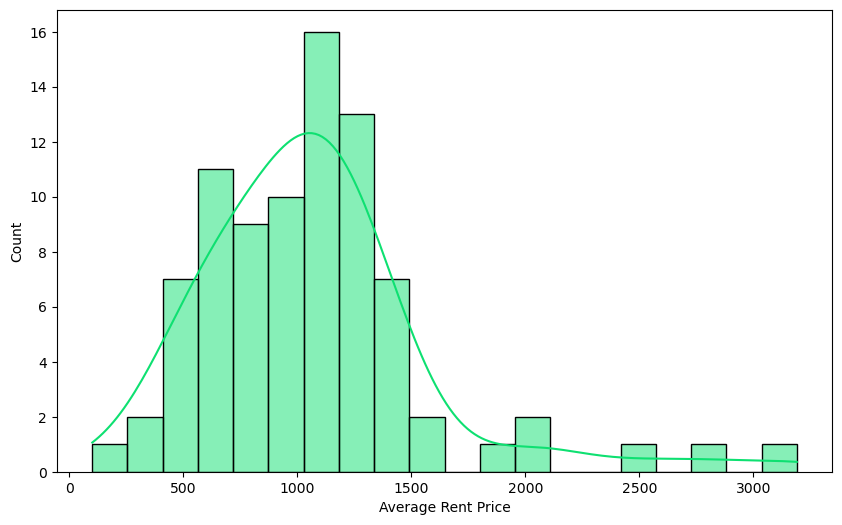

In [822]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data= city_data,
    x='Average Rent Price',
    bins=20,
    kde=True,  
    color='#0EE071'
)

plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Average Rent Price</code> is right skewed:
  <ul>
    <li>The mean is bigger than the median.</li>
    <li>The histogram has a bigger tail to the right.</li>
  </ul>
</div>

<h4>Data Type Evaluation:</h4>

<p>As this variable is an <code>int64</code>, there is room to fit until around 9 quintillion.</p>
<p>Changing it to <code>int16</code> would save memory, while keeping room to go until 32 thousands (as the city with the most population is  <code>Zurich</code> with no more than 4 thousand).</p>

In [823]:
city_data['Average Rent Price'] = city_data['Average Rent Price'].astype('int16')

Check:

In [824]:
city_data['Average Rent Price'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 84 entries, 0 to 83
Series name: Average Rent Price
Non-Null Count  Dtype
--------------  -----
84 non-null     int16
dtypes: int16(1)
memory usage: 300.0 bytes


<h3><code>Average Cost of Living</code></h3>
<p style = "font-size : 15px;"><b>Estimated average cost of living for 1 person living in the city (including rent).</b></p>
<p><b>Data Type:</b> int64</p>
<p><b>Missing Values:</b> 0</p>

<h4>Search for outliers:</h4>

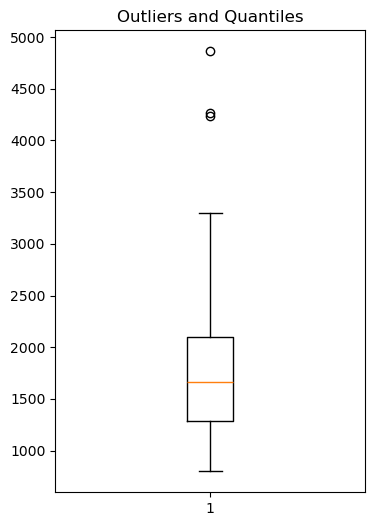

In [825]:
fig, ax1 = plt.subplots(figsize=(4, 6))

ax1.boxplot(city_data["Average Cost of Living"]) 

ax1.set_title("Outliers and Quantiles") 

plt.show()

In [826]:
q1 = city_data['Average Cost of Living'].quantile(0.25)
q3 = city_data['Average Cost of Living'].quantile(0.75)
inter_quartile_range = q3 - q1

outliers = city_data[(city_data['Average Cost of Living'] < q1 - 1.5*inter_quartile_range) | 
              (city_data['Average Cost of Living'] > q3 + 1.5*inter_quartile_range)]

outliers[['City', 'Average Cost of Living']]

,City,Average Cost of Living
8,Zurich,4862
9,Geneva,4263
10,Basel,4239


<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Average Cost of Living</code> has 3 outliers:
  <ul>
    <li><code>Zurich</code></li>
      <li><code>Geneva</code></li>
    <li><code>Basel</code></li>
  </ul>
</div>

<h4>Skewness Analysis:</h4>

In [827]:
mean = city_data['Average Cost of Living'].mean()
median = city_data['Average Cost of Living'].median()

print(f'The mean is {mean}, while the median is {median}.')

The mean is 1808.5833333333333, while the median is 1665.0.


<p>Let's plot a histogram to visualise the skewness:</p>

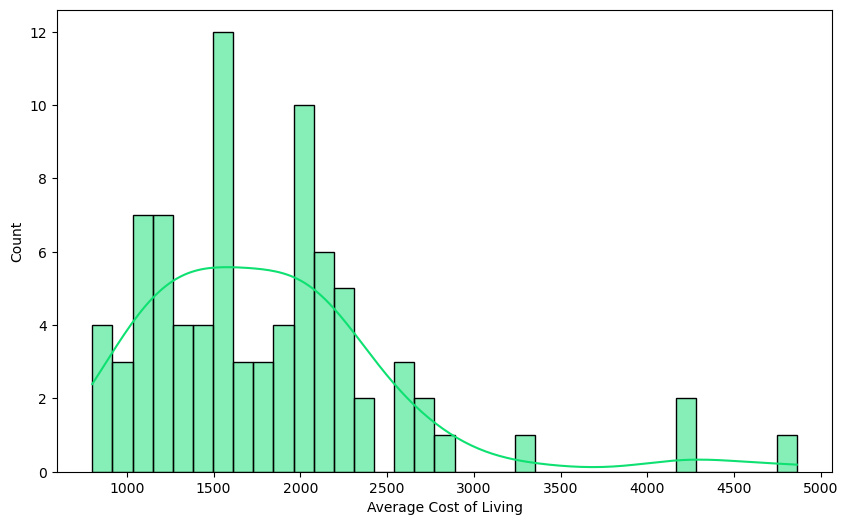

In [828]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data= city_data,
    x='Average Cost of Living',
    bins=35,
    kde=True,  
    color='#0EE071'
)

plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that <code>Average Cost of Living</code> is right skewed:
  <ul>
    <li>The mean is bigger than the median.</li>
    <li>The histogram has a tail to the right.</li>
  </ul>
</div>

<h4>Data Type Evaluation:</h4>

<p>As this variable is an <code>int64</code> by default, so there is room to fit until around 9 quintillion.</p>
<p>Changing it to <code>int16</code> would save some memory, while keeping room to go until 32 thousands (as the city with the most population is  <code>Zurich</code> and has no more than 5 thousand).</p>

In [829]:
city_data['Average Cost of Living'] = city_data['Average Cost of Living'].astype('int16')

Check:

In [830]:
city_data['Average Cost of Living'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 84 entries, 0 to 83
Series name: Average Cost of Living
Non-Null Count  Dtype
--------------  -----
84 non-null     int16
dtypes: int16(1)
memory usage: 300.0 bytes


<h3><code>Average Price Groceries</code></h3>
<p><b>Data Type:</b> float64</p>
<p><b>Missing Values:</b> 78</p>

<h4>Evaluation of variable:</h4>

<p>As this variable only has known values for 6 cities, we can map them, and if needed we could use it to do analysis of those cities independently.</p>
<p>Imputation is completly out of option as we have so little information in the dataset. Making analysis of this variable are possible, but always out of context compared to all the other variables.</p>

In [831]:
non_null_cities = city_data['Average Price Groceries'].notnull()

In [832]:
pd.set_option('display.max_columns', None)

In [833]:
non_null_rows = city_data[non_null_cities]
non_null_rows

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Average Monthly Salary,Average Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country,Arabic,Bengali,Bulgarian,Catalan,Croatian,Czech,Danish,Dutch,English,Estonian,Finnish,French,Gaelic,German,Greek,Hungarian,Irish,Italian,Latvian,Luxembourgish,Maltese,Norwegian,Polish,Portuguese,Romanian,Russian,Scots,Serbian,Slovak,Slovene,Spanish,Swedish,Turkish,Unknown,Urdu,Valencian
0,310.0,2983513,2018818,20.1,10.2,55770.0,3,2500,1050,2061,340.0,2024-06-15 00:00:00,Vienna,Austria,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
4,552.0,645813,417832,24.8,5.3,53311.0,2,2400,827,1200,120.0,2023-07-17 00:00:00,Gent,Belgium,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18,1233.0,2002550,1335299,20.8,3.9,60310.0,3,3200,1030,2000,230.0,2024-11-23 00:00:00,Cologne,Germany,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
56,429.0,794659,491652,20.2,6.2,55283.0,9,1300,1050,1300,256.0,2024-04-13 00:00:00,Florence,Italy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
72,695.0,3008000,1871604,25.4,7.4,42363.0,1,1220,1050,1600,100.0,2024-10-04 00:00:00,Lisbon,Portugal,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
82,1922.0,4843511,3417691,30.0,14.4,38916.0,3,900,450,900,309.0,2023-06-08 00:00:00,Ankara,Turkiye,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
  Concluding that we only have information on this variable on this 6 cities:
  <ul>
    <li><code>Vienna</code></li>
      <li><code>Gent</code></li>
    <li><code>Cologne</code></li>
      <li><code>Florence</code></li>
      <li><code>Lisbon</code></li>
      <li><code>Ankara</code></li>
  </ul>
</div>

<h3><code>Last Data Update</code></h3>
<p style = "font-size : 15px;"><b>Date the data for the city was last updated.</b></p>
<p><b>Data Type:</b> object</p>
<p><b>Missing Values:</b> 0</p>

<h4>Conversion to datetime format:</h4>

<p>This variable is composed of a date and an hour. The hour component is constant to all cities, 00:00:00, so it doensn't give us any useful detail:</p>

In [834]:
city_data.head()

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Average Monthly Salary,Average Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country,Arabic,Bengali,Bulgarian,Catalan,Croatian,Czech,Danish,Dutch,English,Estonian,Finnish,French,Gaelic,German,Greek,Hungarian,Irish,Italian,Latvian,Luxembourgish,Maltese,Norwegian,Polish,Portuguese,Romanian,Russian,Scots,Serbian,Slovak,Slovene,Spanish,Swedish,Turkish,Unknown,Urdu,Valencian
0,310.0,2983513,2018818,20.1,10.2,55770.0,3,2500,1050,2061,340.0,2024-06-15 00:00:00,Vienna,Austria,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1,243.0,375489,250472,20.3,3.0,66689.0,0,3200,1100,2186,NaN,2023-11-03 00:00:00,Salzburg,Austria,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,681.0,3284548,2137425,27.5,10.7,62500.0,3,3350,1200,1900,NaN,2023-04-22 00:00:00,Brussels,Belgium,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,928.0,1139663,723396,27.7,6.2,57595.0,3,2609,900,1953,NaN,2024-08-09 00:00:00,Antwerp,Belgium,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,552.0,645813,417832,24.8,5.3,53311.0,2,2400,827,1200,120.0,2023-07-17 00:00:00,Gent,Belgium,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [835]:
city_data['Last Data Update'] = pd.to_datetime(city_data['Last Data Update'])

In [836]:
city_data.head()

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Average Monthly Salary,Average Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country,Arabic,Bengali,Bulgarian,Catalan,Croatian,Czech,Danish,Dutch,English,Estonian,Finnish,French,Gaelic,German,Greek,Hungarian,Irish,Italian,Latvian,Luxembourgish,Maltese,Norwegian,Polish,Portuguese,Romanian,Russian,Scots,Serbian,Slovak,Slovene,Spanish,Swedish,Turkish,Unknown,Urdu,Valencian
0,310.0,2983513,2018818,20.1,10.2,55770.0,3,2500,1050,2061,340.0,2024-06-15,Vienna,Austria,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1,243.0,375489,250472,20.3,3.0,66689.0,0,3200,1100,2186,NaN,2023-11-03,Salzburg,Austria,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,681.0,3284548,2137425,27.5,10.7,62500.0,3,3350,1200,1900,NaN,2023-04-22,Brussels,Belgium,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,928.0,1139663,723396,27.7,6.2,57595.0,3,2609,900,1953,NaN,2024-08-09,Antwerp,Belgium,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,552.0,645813,417832,24.8,5.3,53311.0,2,2400,827,1200,120.0,2023-07-17,Gent,Belgium,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [837]:
city_data['Last Data Update'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 84 entries, 0 to 83
Series name: Last Data Update
Non-Null Count  Dtype         
--------------  -----         
84 non-null     datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 804.0 bytes


<hr style = "border: 3px solid #0EE071;">
<h2 style = "color : #0EE071;">Export of Cleaned Dataset</h2>
<p style = "font-size : 16px;">As we have cleaned the dataset, we will export this into a <code>.csv</code> file, so that this dataset can be used for other notebooks.</p>
<br>

In [ ]:
#city_data.to_csv('city_data_clean.csv', sep = ',', index = False)

<hr style = "border: 3px solid #0EE071;">
<h2 style = "color : #0EE071;">Data Analysis</h2>
<p style = "font-size : 16px;">Answering questions by analysing the data.</p>
<br>

In [839]:
city_data.head()

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Average Monthly Salary,Average Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update,City,Country,Arabic,Bengali,Bulgarian,Catalan,Croatian,Czech,Danish,Dutch,English,Estonian,Finnish,French,Gaelic,German,Greek,Hungarian,Irish,Italian,Latvian,Luxembourgish,Maltese,Norwegian,Polish,Portuguese,Romanian,Russian,Scots,Serbian,Slovak,Slovene,Spanish,Swedish,Turkish,Unknown,Urdu,Valencian
0,310.0,2983513,2018818,20.1,10.2,55770.0,3,2500,1050,2061,340.0,2024-06-15,Vienna,Austria,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1,243.0,375489,250472,20.3,3.0,66689.0,0,3200,1100,2186,NaN,2023-11-03,Salzburg,Austria,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,681.0,3284548,2137425,27.5,10.7,62500.0,3,3350,1200,1900,NaN,2023-04-22,Brussels,Belgium,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,928.0,1139663,723396,27.7,6.2,57595.0,3,2609,900,1953,NaN,2024-08-09,Antwerp,Belgium,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,552.0,645813,417832,24.8,5.3,53311.0,2,2400,827,1200,120.0,2023-07-17,Gent,Belgium,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<h3>1. How did you handle missing values and duplicate records in the dataset? Justify your approach.</h3>

<p>As seen above, the duplicated records were mapped and then we compared them to be sure that they were indeed duplicated (not two versions of data corresponding to the same city). After that we dropped the duplicated records.</p>
<p>As for the missing values, each case of missing values was carefully analysed in the context of the shape of the variable and city. Most of them were single missing values and it was possible to impute, using the median, so that we can do general analysis without worring about missing values. The only exception to this was the variable 'Average Price Groceries' that only had 6 known values, this one we just mapped the values (discovered which cities corresponded to the known values).</p>

<h3>2. Frequencies and soft analysis</h3>

<h4>a) Which country appears most frequently in the dataset? How many cities are associated with it? </h4>

In [840]:
count_countries = city_data['Country'].value_counts() #get a series with the count of how many times each country appears
most_frequent_country = count_countries.index[0] #filter the most frequent country
print(f'The most frequent country in the dataset is {most_frequent_country}. And appears {count_countries.max()} times.')

The most frequent country in the dataset is Germany. And appears 10 times.


<h4>b) How many cities are present in total? How many are associated with Greece? </h4>

In [841]:
total_num_cities = len(city_data) # each city is one row in city_data, so let's count them (we have eliminated duplicates)
num_greece_cities = int(count_countries['Greece']) #from the series of count cities per country, let's filter Greece
print(f'There are {total_num_cities} cities in this dataset and {num_greece_cities} of them are greek.')

There are 84 cities in this dataset and 2 of them are greek.


<h4>c) Which is the least spoken language in the dataset? Which are the top 3 most spoken languages? </h4>

In [842]:
list_frequencies_language = city_data.iloc[:, 14:].sum().sort_values(ascending=False).drop('Unknown') # from the columns that represent dummy variables for each language, let's sum them and sort it
least_spoken_count = list_frequencies_language.min() #take the minimum frequency, presumebly 1
least_spoken_languages = list_frequencies_language[list_frequencies_language == least_spoken_count].index.tolist() #filter the languages of those frequencies and futing them into a list

top_3_frequencies = list_frequencies_language.head(3) #take the maximum 3 frequencies
top_3_languages = top_3_frequencies.index.tolist() #filter the language

print(f'The least spoken languages are:', end = ' ')
for language in least_spoken_languages:
    print (language, end = ', ')
print(f'the top 3 most spoken languages are:', end = ' ')
for language in top_3_languages:
    print(language, end = ', ')

The least spoken languages are: Catalan, Bengali, Estonian, Latvian, Luxembourgish, Serbian, Maltese, Romanian, Slovak, Slovene, Valencian, the top 3 most spoken languages are: English, German, Turkish, 

<h3>3. Upload dates and updates</h3>

<h4>a) Entries uploaded before April 2023 need to be updated. Which cities would require an update? </h4>

In [843]:
upload_date = pd.to_datetime('2023-04-01') #defining the cutoff date that separates entries that need update
outdated_entries = city_data['Last Data Update'] < upload_date #filtering into a new list the entries that need update
outdated_cities = city_data.loc[outdated_entries, ['City']] #creating a new dataset with the name of the cities that need update

In [844]:
print(f'The cities that require and update are:')
outdated_cities

The cities that require and update are:


,City
10,Basel
17,Munich
19,Frankfurt am Main
36,Lyon
57,Venice
80,Gothenburg


<h4>b) How many days ago was the last update? On what day, month, and year did it occur? </h4>

In [845]:
today = pd.to_datetime(dt.date.today()) #creating a variable with today's date
outdated_cities = city_data.loc[outdated_entries, ['City', 'Country', 'Last Data Update']] #creating a dataset filtered with the rows (entries that need update) and columns we need
outdated_cities['Days Since Update'] = (today - outdated_cities['Last Data Update']).dt.days #calculating the days passed using datetime arithmetics

outdated_cities['Update Day'] = outdated_cities['Last Data Update'].dt.day #extracting the day of the last update
outdated_cities['Update Month'] = outdated_cities['Last Data Update'].dt.month #extracting the month of the last update
outdated_cities['Update Year'] = outdated_cities['Last Data Update'].dt.year #extracting the year of the last update

In [846]:
print(f'Count of days since last update.')
outdated_cities.loc[:, ['City', 'Days Since Update']]

Count of days since last update.


,City,Days Since Update
10,Basel,1065
17,Munich,1009
19,Frankfurt am Main,1049
36,Lyon,994
57,Venice,1002
80,Gothenburg,1015


In [847]:
print(f'Day, Month and Year that the last update occured:')
outdated_cities.loc[:, ['City', 'Update Day', 'Update Month', 'Update Year']]

Day, Month and Year that the last update occured:


,City,Update Day,Update Month,Update Year
10,Basel,19,1,2023
17,Munich,16,3,2023
19,Frankfurt am Main,4,2,2023
36,Lyon,31,3,2023
57,Venice,23,3,2023
80,Gothenburg,10,3,2023


<h3>4. Correlation Analysis</h3>

<h4>a) How are the Unemployment Rate and GDP per Capita distributed and related? What does this relationship suggest? Provide a visual representation.</h4>

<p>Firstly let's see how is each of these 2 variables distributed using histograms with kde's:</p>

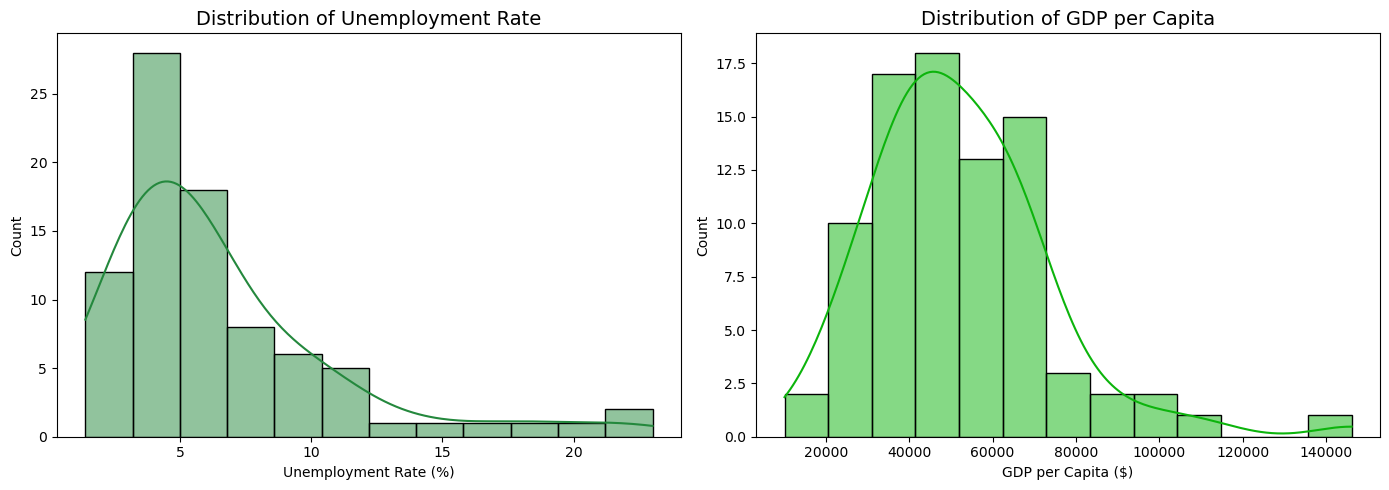

In [848]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(city_data['Unemployment Rate'], kde=True, ax=axes[0], color="#24883D")
axes[0].set_title('Distribution of Unemployment Rate', fontsize=14)
axes[0].set_xlabel('Unemployment Rate (%)')

sns.histplot(city_data['GDP per Capita'], kde=True, ax=axes[1], color="#0CB40C")
axes[1].set_title('Distribution of GDP per Capita', fontsize=14)
axes[1].set_xlabel('GDP per Capita ($)')

plt.tight_layout()
plt.show()

<p>As we knew from previous analysis, there two variables are right skewed. While <code>GDP per capita</code> might have outliers due to some super-wealthy cities, <code>Unemployement Rate</code> might have outliers due to cities with big unemployement issues.</p>

<p>The most straight forward way to see how 2 continuous variables are related is to draw a scatter plot.</p>
<p>We will draw an initial scatter plot and analyse it considering: imputated values of these 2 variables, outliers and overall context.</p>

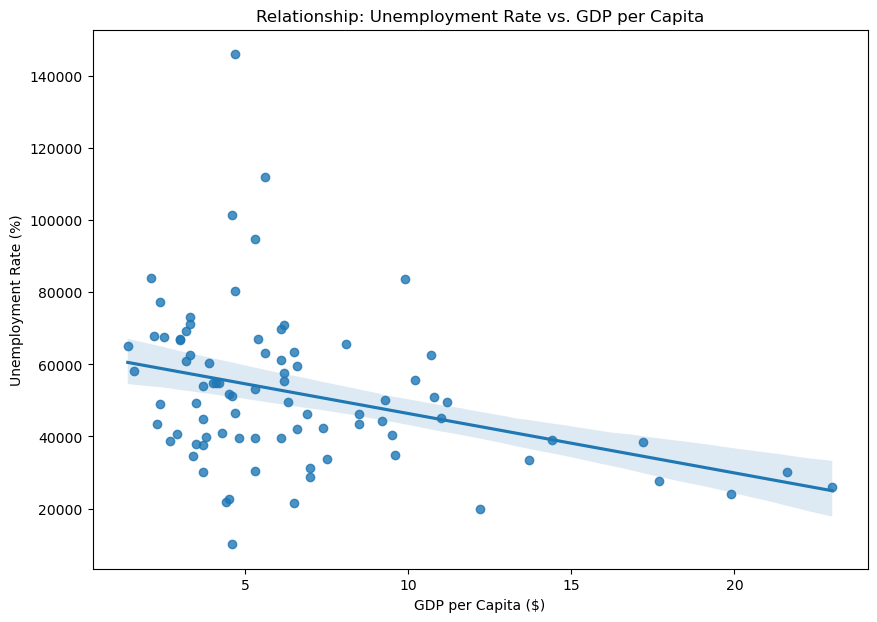

In [849]:
plt.figure(figsize=(10, 7)) #creating the plt figure
 
sns.regplot(    #a regplot will plot the scatter plot with the regression line
                data = city_data, #selecting the dataset
                x = 'Unemployment Rate', #x axis variable, which is 'Unemployment Rate'
                y = 'GDP per Capita') #doing the same for y axis - with 'GDP per Capita'

plt.title('Relationship: Unemployment Rate vs. GDP per Capita') #defining the title

plt.xlabel('GDP per Capita ($)') #making the x label
plt.ylabel('Unemployment Rate (%)') #making the y label

plt.show() #diplay

In [850]:
correlation = city_data['GDP per Capita'].corr(city_data['Unemployment Rate'])
print(f"Correlation Coefficient: {correlation:.2f}")

Correlation Coefficient: -0.34


<p>The scatter plot reveals a negative correlation of -0.34 (not much strong). This suggests that cities with higher economic output (GDP) tend to have lower unemployment rates, validating some kind of link between economic health and job availability.</p>
<p>As <code>GDP per Capita</code> increases, <code>Unemployment Rate</code> decreases - moving to a city with higher economic output generally improves your chances of finding a stable job market, or, in another view, a city with greater unemployement rate will suffer on its economic output.</p>
<p>We should also remark that this correlation has a coefficient of only -0.34, which is not very strong and thus, there is no certain move to a given city that will grant you a job.</p>

<br>
<h4>b) Which are the top 5 cities with the largest difference between the Average
Monthly Salary and Average Cost of Living?
What about the top 5 countries with the smallest average difference?
Show these results with meaningful visualizations.</h4>

<p>To answer this question, we have to follow a series of steps:</p>
<ol><li>Creating one varible that represents the differente between <code>Age Montly Salary</code> and <code>Average Cost of Living</code> - the <code>Monthly Savings</code>;</li>
<li>Filter the 5 cities with largest <code>Monthly Savings</code>;</li>
<li>Group by country, with the average <code>Monthly Savings</code>, and filter 5 coruntries with smallest.</li></ol>
<p>Throughout this process, we wil add visualizations:</p>

In [851]:
# 0.
ni_df = city_data.copy() #creating a copy df so that we do not mess with the original city_data

In [852]:
# 1.
ni_df['Monthly Savings'] = ni_df['Average Monthly Salary'] - ni_df['Average Cost of Living'] #using pandas arithmetics to subtract the Avg Cost of Living
#to the Average Monthly Salary

In [853]:
# V1
fig1 = px.bar(
    ni_df, #using the ni_df dataset
    x='Monthly Savings', #selecting 'Monthly Savings' for x axis
    y='City', #and 'City' for y
    orientation='h', #horizontal bars are easier to read for names
    title='European Cities by Monthly Savings', #title 
    labels={'Monthly Savings': 'Monthly Savings ($)', 'City': ''}, #x-axis label and make y-axis label empty
    color='Monthly Savings', #make colours based on 'Monthly Savings' values
    color_continuous_scale='Greens', #choosing Green for color
    hover_data=['Average Monthly Salary', 'Average Cost of Living', 'Country'] #selecting what we want to see when hovering over bars
)
fig1.update_layout(showlegend=False, coloraxis_showscale=False) #removing legend and color scale for simplicity
fig1.show()

<p><b>V1 interpretation:</b> From this general view, we can already tell that the Monthly Savings is a variable very diverse throughout Europe, therefore, analysis by country and region could be of great help if we want to undertand what happens to Monthly Savings throughout Europe.</p>
<br>

In [854]:
# 2. 
top_5_savings_city = ni_df[['City', 'Country', 'Monthly Savings', 'Average Monthly Salary', 'Average Cost of Living']].sort_values(by='Monthly Savings', ascending=False).head(5)

print('Top 5 Cities with LARGEST Monthly Savings:')
top_5_savings_city

Top 5 Cities with LARGEST Monthly Savings:


,City,Country,Monthly Savings,Average Monthly Salary,Average Cost of Living
10,Basel,Switzerland,2127,6366,4239
34,Tampere,Finland,1900,3500,1600
33,Helsinki,Finland,1850,3900,2050
8,Zurich,Switzerland,1774,6636,4862
9,Geneva,Switzerland,1531,5794,4263


In [855]:
#V2

#Creating a variable that puts the savings in relative terms to the salary - beyond the biggest saving (in absolute terms), let's see the most efficient saver
top_5_savings_city['Savings Rate'] = (top_5_savings_city['Monthly Savings'] / top_5_savings_city['Average Monthly Salary']) * 100

fig1 = px.bar(
    top_5_savings_city, #using the filtered df 
    x='Monthly Savings', #plotting the Monthly Savings (absolute terms)
    y='City', #City on y
    orientation='h', #horizontal bars
    color='Savings Rate', #colloring the bars by Savings Rate (relative terms)
    color_continuous_scale='Greens',
    title='<b>Top 5 Cities for Savings: Absolute (€) vs. Efficiency (%)</b><br><i>Color represents the % of salary saved (Savings Rate)</i>', #HTML tags for formatting the title
    labels={'Monthly Savings': 'Monthly Savings (€)', 'Savings Rate': 'Savings Rate (%)', 'City': ''},
    hover_data=['Country', 'Monthly Savings', 'Savings Rate']
)

fig1.update_layout(coloraxis_colorbar_title="Savings Rate (%)") #updating the name of the color bar
fig1.show()

<p><b>V2 interpretation:</b> From this visualization, we can see that eventhough Basel is the city where, on average, people save more (in absolute terms get more money inside their pockets at the end of the month), if we take into account the universe of money people have for their spendings each month, Finnish people (living in Helsinki and Tampere) are the ones who can keep more money inside their pockets relatively to what they earn.</p>
</br>

In [856]:
# 3. 
savings_by_country = ni_df.groupby('Country')['Monthly Savings'].mean().reset_index() #grouping by country using the mean of the montlhy savings
bottom_5_countries_savings = savings_by_country.sort_values(by = 'Monthly Savings', ascending = True).head(5) #sorting and filtering the bottom 5
bottom_5_countries_savings['Country'] = bottom_5_countries_savings['Country'].astype('string') #removing the categories so that we can plot only the countries we wish

print('Top 5 Countries with SMALLEST Average Monthly Savings:')
bottom_5_countries_savings

Top 5 Countries with SMALLEST Average Monthly Savings:


,Country,Monthly Savings
21,Portugal,-207.500000
11,Greece,-125.000000
23,Slovak Republic,-50.000000
28,Turkiye,-25.000000
20,Poland,-16.666667


In [857]:
#V3

bottom_5_names = bottom_5_countries_savings['Country'].tolist() #creting a list with the names of the bottom 5 countries
bottom_5_df = ni_df[ni_df['Country'].isin(bottom_5_names)].copy() #creating a datset with the cities that belong to the bottom 5 countries and variables we had originally in ni_df

bottom_5_df['Country'] = pd.Categorical( #taking care of the categories in 'Country', we only need 5 categories - 5 countries
    bottom_5_df['Country'], 
    categories=bottom_5_names)


fig = px.box(
    bottom_5_df,
    x='Country', #each country gets a 'bar'/space on the x axis
    y='Monthly Savings', #plotting the Monthly Savings in the y (making boxplots for the distribution by city)
    points='all', #show one point per city in the designated country bar
    color='Country', #color by country
    title='<b>Monthly Savings Distribution in Low-Savings Countries by City</b><br><i>Boxplots show range while dots represent individual cities</i>', #HTML tags for title formatting
    labels={'Monthly Savings': 'Monthly Savings (€)', 'Country': 'Country in Bottom 5 by Savings'},
    hover_data=['City', 'Average Monthly Salary', 'Average Cost of Living']
)

fig.add_hline(y=0, line_dash="dash", line_color="green", annotation_text="0€") #add a red line at 0 

fig.update_layout(showlegend=False)
fig.show()

<p><b>V3 interpretation:</b> This visualization is rather complex, so let's break it by parts:</p>
<ul><li><i>Boxplots</i>: We have one boxplot by country, showing the range and distribution of its cities; counties with less cities, have less significance in our analysis, for example Portugal has 4 cities and thus a more robust boxplot than Slovak Republic. Therefore, the purpose of this visualization is not to compare different countries - <b>it is to see how we got the answer</b> for this question: bottom 5 countries by average monthly savings. </li>
<li><i>Points</i>: Each point represents a city, they are grouped by countries, and we can see how Portugal has a city, Coimbra, almost reaching the equitity between Average Monthly Salary and Average Cost of Living, while Lisbon is much further from that scenario, while we can tell that any city in Portugal is below the 0€ on savings. On the other hand, Poland as one city a bit below Coimbra, nevertheless Poland has one city - Lodz - right on the 0€ line and another - Warsow - right above the line, telling us that eventhough two cities in Poland have no negative Monthly Savings, the only one that has it negative is 'pulling' the other ones down when we look at Poland as a whole.</li></ul>

</br>

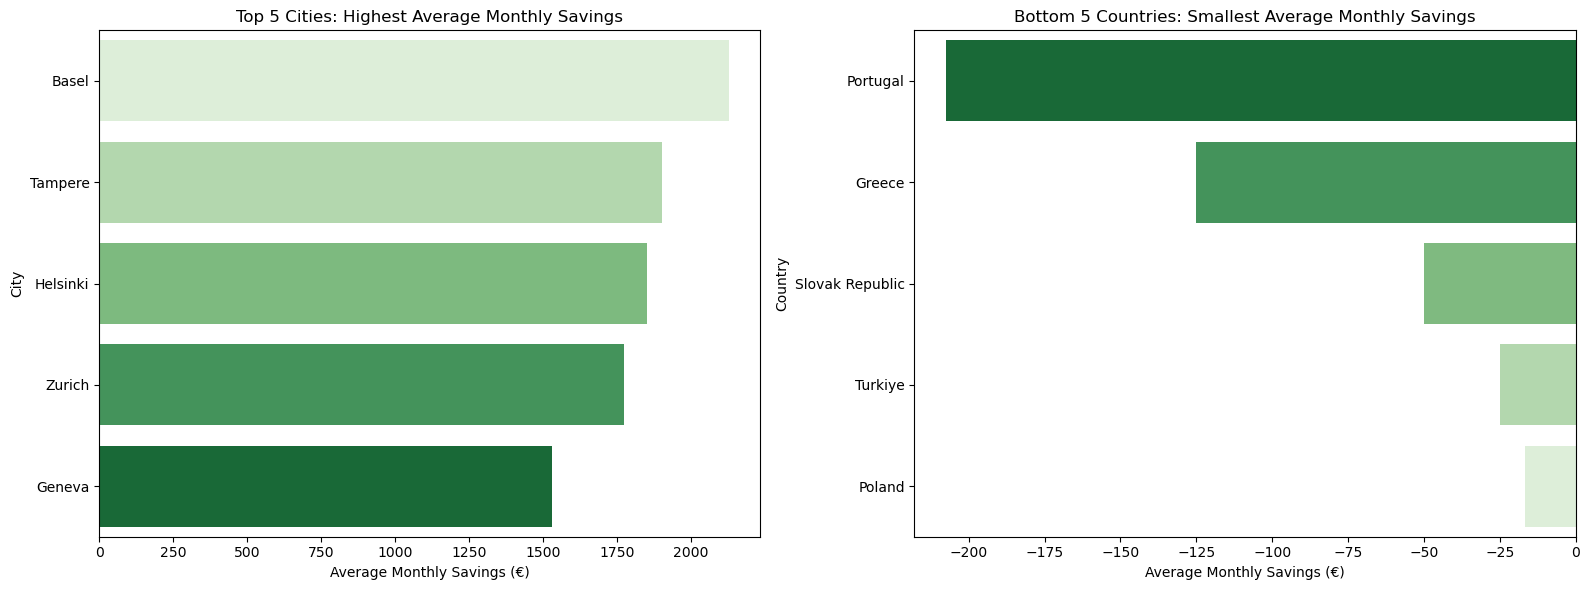

In [858]:
#VA - Visualizations of the answers 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ax 1: Top 5 Cities
sns.barplot(x='Monthly Savings', y='City', data=top_5_savings_city, ax=axes[0], palette='Greens')
axes[0].set_title('Top 5 Cities: Highest Average Monthly Savings')
axes[0].set_xlabel('Average Monthly Savings (€)')

# Ax 2: Bottom 5 Countries
sns.barplot(data=bottom_5_countries_savings, x='Monthly Savings', y='Country', ax=axes[1], palette='Greens_r')
axes[1].set_title('Bottom 5 Countries: Smallest Average Monthly Savings')
axes[1].set_xlabel('Average Monthly Savings (€)')

plt.tight_layout()
plt.show()

<br>
<h4>c) Which is the best city for someone seeking:
<ul><li>an average monthly salary above €1600</li>
<li>a cost of living below €900</li>
<li>a country suitable for starting a family (with a relatively larger youth population)?</li></ul> </h4>


<p>Apparently, one strategy to accomplish this is to: filter the cities by <code>Average Monthly Salary > €1600</code> and <code>Average Cost of Living < €900</code>. After this, get the dataset ordered by <code>Youth Dependency Ratio</code> (by descending order, because we want to select the one with relatively larger youth population, and thus biggest Youth Dependency Ratio).</p>
<p>Right after, we can just select the country raked 1st on this ordered dataset - there <b>would</b> be our answer.</p>

In [859]:
#family_city_candidates = city_data[
#    (city_data['Average Monthly Salary'] > 1600) & 
#    (city_data['Average Cost of Living'] < 900)
#].copy() #filtering the cities that meet the 2 initial objective conditions

#best_family_city = family_city_candidates.sort_values(by='Youth Dependency Ratio', ascending=False) #sorting the filtered cities by YDR


#if not best_family_city.empty:
#    print('The best city ')
#    print(best_family_city[['City', 'Country', 'Average Monthly Salary', 'Average Cost of Living', 'Youth Dependency Ratio']].head(1)) #selecting the top 1
#else:
#    print("No cities matched the conditions.") #handling the case where no city meets the criteria

<p>As seen above, there are no cities that match the objective conditions.</p>
<p>Comming to the conclusion that there is no city that is <b>the best</b>, let's design a strategy that gets us the <i>best</i> city we can get:</p>

In [860]:
print(f'Number of cities with Average Monthly Salary > 1600: {city_data[city_data["Average Monthly Salary"] > 1600].shape[0]}') #no. cities matching condition 1

Number of cities with Average Monthly Salary > 1600: 54


In [861]:
print(f'Number of cities with Average Cost of Living < 900: {city_data[city_data["Average Cost of Living"] < 900].shape[0]}') #no. cities matching condition 2

Number of cities with Average Cost of Living < 900: 1


<p>There is only one city that matches the 2nd condition while 54 cities match the 1st condition.<p>
<p>Given that we can't achieve the perfect city, let's start by filtering the cities that comply with the 1st condition, as they are plenty.</p>

In [862]:
family_city = city_data[city_data["Average Monthly Salary"] > 1600] #filtering the cities that match 1st condition

<p>Now we proceed to calculate how far each of these cities are from the goal of the 2nd condition. For this, we created a variable <code>Distance_2nd</code> that is the distance of <code>Average Cost of Living</code> to 900 (the goal).</p>

In [863]:
family_city = family_city[['City', 'Country', 'Average Monthly Salary', 'Average Cost of Living', 'Youth Dependency Ratio']] #selecting only the columns we need
family_city['Distance_2nd'] = (family_city['Average Cost of Living'] - 900) #creating a new column that calculates the distance from the 2nd condition goal
family_city.head()

,City,Country,Average Monthly Salary,Average Cost of Living,Youth Dependency Ratio,Distance_2nd
0,Vienna,Austria,2500,2061,20.1,1161
1,Salzburg,Austria,3200,2186,20.3,1286
2,Brussels,Belgium,3350,1900,27.5,1000
3,Antwerp,Belgium,2609,1953,27.7,1053
4,Gent,Belgium,2400,1200,24.8,300


<p>As the guidelines talk about '<b>country</b> suitable for starting a family', we will calculate the Average <code>Youth Dependency Ratio</code> by country, and assign them to the cities.

In [864]:
family_country = city_data.groupby('Country')['Youth Dependency Ratio'].mean().reset_index() #grouping by country getting the mean YDR

family_city = family_city.merge(family_country, on='Country', how='left') #merging the country YDR to the city dataset
family_city = family_city.rename(columns={'Youth Dependency Ratio_y': 'Country YDR'}) #renaming the country YDR column
family_city = family_city[['City', 'Average Monthly Salary', 'Average Cost of Living', 'Country YDR', 'Distance_2nd']] #reordering ad filtering columns

family_city.head()


,City,Average Monthly Salary,Average Cost of Living,Country YDR,Distance_2nd
0,Vienna,2500,2061,20.2000,1161
1,Salzburg,3200,2186,20.2000,1286
2,Brussels,3350,1900,26.4075,1000
3,Antwerp,2609,1953,26.4075,1053
4,Gent,2400,1200,26.4075,300


<p>Now, we have:</p>
<ul><li>Only the cities that fulfill the <b>1st condition</b>
<li>The distance of each city to the goal of the <b>2nd condition</b>
<li>The Average YDR of the country the city is in</li></ul>
<br>
<p>Now it comes to a step of seeing which is the city that has a bigger <code>Country YDR</code> and a smaller <code>Distance_2nd</code>. Let's apply a <code>.sort_value()</code>, giving priority to the smaller <code>Distance_2nd</code>, as this was the objective condition, while the 3rd condition is pretty much relative.</p>

In [865]:
family_city = family_city.sort_values(by=['Distance_2nd', 'Country YDR'], ascending=[True, False]) #sorting by distance to 2nd condition and country YDR

family_city.head()

,City,Average Monthly Salary,Average Cost of Living,Country YDR,Distance_2nd
26,Seville,2300,1150,23.3400,250
4,Gent,2400,1200,26.4075,300
25,Valencia,2400,1300,23.3400,400
27,Malaga,2200,1400,23.3400,500
18,Dresden,3050,1530,21.4700,630


In [866]:
print(f'The "best" city would be: {family_city.iloc[0]["City"]}')

The "best" city would be: Seville


<p>Therefore, through our method of finding the best city according to the conditions, we got <b>Seville</b>.</p>

<p>As we did not find the ideal city to live, here are the cities that comply with the 1st and 2nd condition, as well as the top 1 suitable city for the 3rd condition:</p>

In [867]:
#print(f'Cities with Average Monthly Salary > 1600:')
#city_data[city_data["Average Monthly Salary"] > 1600][['City', 'Average Monthly Salary', 'Average Cost of Living', 'Youth Dependency Ratio']]

In [868]:
#print(f'City with Average Cost of Living < 900:')
#city_data[city_data["Average Cost of Living"] < 900][['City', 'Average Monthly Salary', 'Average Cost of Living', 'Youth Dependency Ratio']]

In [869]:
#print('City with the highest Youth Population (highest Youth Dependency Ratio):')
#city_data[['City', 'Average Monthly Salary', 'Average Cost of Living', 'Youth Dependency Ratio']].sort_values(by='Youth Dependency Ratio', ascending=False).head(1)

<p>Look at this, if the 1st condition (<code>Average Monthly Salary > 1600</code>) would not be very important, Adana is the only city that complies with the 2nd condition and has a remarkebly high YDR!</p>

<h3>5. What are three additional insights you find meaningful when comparing the
given cities?</h3>

<h4><b>Insight A</b>: Rent/Salary Ratio - What are the best/worst cities to live relating Rent and Salary?</h4>

<p>Here we will create a variable <code>Rent/Salary Ratio</code> for each city. With this we want to see the percentage of the salaries people spend on rent in each city. A larger <code>Rent/Salary Ratio</code> might indicate a bad city to live.

In [870]:
rsr_df = city_data.copy()
rsr_df['Rent/Salary Ratio'] = rsr_df['Average Rent Price'] / rsr_df['Average Monthly Salary'] * 100

<p>Let's make a barplot of all cities in pyplot, colored by country, to have an outline of this variable and be able to search interactivle to cities, countries and values:</p>

In [871]:
fig1 = px.bar(
    rsr_df, #using the filtered df 
    x='Rent/Salary Ratio', #plotting the Rent/Salary Ratio (absolute terms)
    y='City', #City on y
    orientation='h', #horizontal bars
    color='Country', #colloring the bars by Country
    color_continuous_scale='Greens',
    title='<b>Cities by Rent/Salary Ratio</b><br><i>Color represents a country</i>', #HTML tags for formatting the title
    labels={'Rent/Salary Ratio': 'Rent/Salary Ratio', 'City': ''},
    hover_data=['Country', 'Rent/Salary Ratio', 'Average Monthly Salary', 'Average Rent Price']
)

fig1.update_layout(coloraxis_colorbar_title="Country") #updating the name of the color bar
fig1.show()

<p>After this, we should make a boxplot, to have a more visually simple way of telling the distribution of our newly created variable:</p>

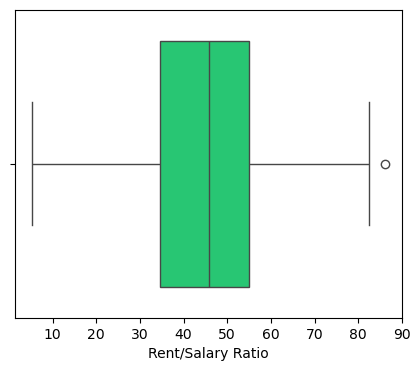

In [872]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(
    data=rsr_df,
    x='Rent/Salary Ratio',
    color='#0EE071'
)

fig.show()

<p>We can see that we have an outlier (probably Lisbon, from previous barplot), and the cities between Q3 and the city with the biggest Rent/Salary Ratio is a range approximatly from ~55% to ~85%. This range is the range of cities where we shouldn't move if we don't expect to pay too much rent compared to salary.</p>

In [873]:
p75 = rsr_df['Rent/Salary Ratio'].quantile(0.75)


In [874]:
high_rent_cities = rsr_df[['City', 'Country','Rent/Salary Ratio', 'Average Monthly Salary', 'Average Rent Price']][rsr_df['Rent/Salary Ratio'] > p75]
high_rent_cities = high_rent_cities.sort_values(by='Rent/Salary Ratio', ascending=False)
print('Cities with Rent/Salary Ratio above Q3:')
high_rent_cities

Cities with Rent/Salary Ratio above Q3:


,City,Country,Rent/Salary Ratio,Average Monthly Salary,Average Rent Price
72,Lisbon,Portugal,86.065574,1220,1050
53,Milan,Italy,82.352941,1700,1400
57,Venice,Italy,82.142857,1400,1150
73,Porto,Portugal,81.818182,1100,900
56,Florence,Italy,80.769231,1300,1050
71,Cracow,Poland,71.428571,1400,1000
77,Bratislava,Slovak Republic,70.833333,1200,850
74,Braga,Portugal,70.000000,1000,700
28,Barcelona,Spain,69.245463,2094,1450
38,London,United Kingdom,69.090909,2750,1900


<p>From this list, we should say that: <b>Lisbon</b>, <b>Milan</b>, <b>Venice</b>, <b>Porto</b> and <b>Florence</b> are the ones with more than 80% in this Rent/Salary ratio.</p>

<p>Additionally, we can see what are the cities to look if you are someone who doesn't want to spend too much of their salary in rent.</p>
<p>The range between the city with smallest ratio rent/salary and the Q1 is from approximatly ~5% to ~35%.</p>

In [875]:
p25 = rsr_df['Rent/Salary Ratio'].quantile(0.25)

In [876]:
low_rent_cities = rsr_df[['City', 'Country','Rent/Salary Ratio', 'Average Monthly Salary', 'Average Rent Price']][rsr_df['Rent/Salary Ratio'] < p25]
low_rent_cities = low_rent_cities.sort_values(by='Rent/Salary Ratio', ascending=True)
print('Cities with Rent/Salary Ratio below Q1:')
low_rent_cities

Cities with Rent/Salary Ratio below Q1:


,City,Country,Rent/Salary Ratio,Average Monthly Salary,Average Rent Price
13,Prague,Czechia,5.376344,1860,100
34,Tampere,Finland,24.285714,3500,850
22,Dresden,Germany,26.229508,3050,800
33,Helsinki,Finland,26.923077,3900,1050
30,Seville,Spain,28.260870,2300,650
21,Leipzig,Germany,28.571429,2800,800
26,Odense,Denmark,29.411765,3400,1000
62,Amsterdam,Netherlands,30.666667,3750,1150
37,Toulouse,France,30.769231,2600,800
68,Stavanger,Norway,31.428571,3500,1100


<p>Here, we have to <b>remark that Prague is the city where Rent/Salary ratio is very low, standing at 5.4%</b></p>

<h4><b>Insight B</b>: What is the most promising city to the future?</h4>

<p>For this insight, we will try to understand <code>Youth Dependence Ratio</code> and <code>GDP per capita</code>. A city with high <code>Youth Dependence Ratio</code> should be a relatively young city (large population below 15 years old), thus in the future those cities might be the ones with larger Working Age Population and the mos thriving cities. While <code>GDP per capita</code> is the measure of wealth produced by each city in the present.</p>
<p>By analysing this two variables, we can get a good view of what is the city that has, in the present day, the most wealth, and keeps promising to future wealth.</p>

<p>The strategy to show the insight here will be as follows:</p>
<ol><li>Calculate the medians of <code>GDP per capita</code> and <code>Youth Dependncy Ratio</code>;</li>
<li>Categorise each city regarding the 2 measures calculated previously;</li>
<li>Make an interactive scatter plot with all cities categorised and the median lines;</li>
<li>List the most promising cities (the cities above 2 medians).</li></ol>

In [877]:
mpc_df = city_data[['City', 'Country', 'GDP per Capita', 'Youth Dependency Ratio', 'Population']].copy() #creating a new df with only the relevant columns

median_gdp = mpc_df['GDP per Capita'].median() #calculating the GDP median
median_youth = mpc_df['Youth Dependency Ratio'].median() #calculating the YDR median

In [878]:
def categorize_city(row):
    """Funtion that catogorizes each city based on GDP per Capita and Youth Dependency Ratio
    According to the medians calculated previously, there should be 4 categories:
    - Promising Cities (Wealth + Future): High GDP per Capita & High Youth Dependency Ratio
    - Aging Cities (High GDP, Low Youth): High GDP per Capita & Low Youth Dependency Ratio
    - Developing Potential (Low GDP, High Youth): Low GDP per Capita & High Youth
    - Struggling (Low GDP, Low Youth): Low GDP per Capita & Low Youth Dependency Ratio
    """
    if row['GDP per Capita'] > median_gdp and row['Youth Dependency Ratio'] > median_youth:
        return 'Promising Cities (Wealth + Future)'
    elif row['GDP per Capita'] > median_gdp:
        return 'Aging Cities (High GDP, Low Youth)'
    elif row['Youth Dependency Ratio'] > median_youth:
        return 'Developing Potential (Low GDP, High Youth)'
    else:
        return 'Struggling (Low GDP, Low Youth)'

mpc_df['City Category'] = mpc_df.apply(categorize_city, axis=1)

In [879]:
fig = px.scatter(
    mpc_df, #using the mpc_df dataset we prepared
    x='GDP per Capita', #GDP for the x
    y='Youth Dependency Ratio', #YDR for the y
    color='City Category', #color by categories we defined
    size='Population', #size by population to have a more robust view - also seeing big population centers
    hover_name='City', #hover infos - city name in big
    hover_data=['Country', 'GDP per Capita', 'Youth Dependency Ratio', 'Population'], #hover infos
    title='<b>The Most Promising Cities</b><br><i>Top Right = High Present Wealth & High Future Labor Force</i>', #title using HTML tags
    labels={
        'GDP per Capita': 'Present Wealth: GDP per Capita ($)',
        'Youth Dependency Ratio': 'Future Promise: Youth Dependency Ratio'
    },
    color_discrete_map={
        'Promising Cities (Wealth + Future)': '#00CC96', # Green for promising cities
        'Aging Cities (High GDP, Low Youth)': '#AB63FA',
        'Developing Potential (Low GDP, High Youth)': '#FFA15A',
        'Struggling (Low GDP, Low Youth)': '#EF553B'
    }
)


fig.add_hline(y=median_youth, line_dash="dash", line_color="gray", annotation_text="Median Youth Ratio") #drawing the meadian lines
fig.add_vline(x=median_gdp, line_dash="dash", line_color="gray", annotation_text="Median GDP") #drawing the meadian lines

fig.show()

In [880]:
promising_cities = mpc_df[mpc_df['City Category'] == 'Promising Cities (Wealth + Future)'] #filtering only the promising cities
print("Cities with High Wealth AND High Future Potential - the PROMISING CITIES:")
promising_cities[['City', 'Country', 'GDP per Capita', 'Youth Dependency Ratio']].sort_values('GDP per Capita', ascending=False).reset_index(drop=True)

Cities with High Wealth AND High Future Potential - the PROMISING CITIES:


,City,Country,GDP per Capita,Youth Dependency Ratio
0,Cork,Ireland,146094.0,31.20
1,Dublin,Ireland,101483.0,29.80
2,Geneva,Switzerland,83747.0,23.80
3,Bratislava,Slovak Republic,77457.0,26.00
4,Amsterdam,Netherlands,73065.0,24.00
5,Stockholm,Sweden,70950.0,28.50
6,London,United Kingdom,69863.0,29.10
7,Warsaw,Poland,67994.0,25.70
8,Oslo,Norway,67128.0,26.40
9,Utrecht,Netherlands,67062.0,26.20


<h4><b>Insight C</b>: What is the most promising city to the future?</h4>

<p>Throughout our various analysis, one thing is clear: <code>Average Monthly Salary</code>, <code>Average Cost of Living</code> and <code>Average Rent Price</code> have very strong correlations in between them. So we would like to start on that, correlating the Savings one can do in each city with what one has to pay. Linking this to the percentage of spending designated to rent.</p>

In [881]:
icdf = city_data[['City', 'Country', 'Average Cost of Living', 'Average Monthly Salary', 'Average Rent Price', 'Population']].copy()

<p>Firstly, we will create 4 variables that are directly dependent on <code>Average Monthly Salary</code>, so that we can compare this and make trustful insights.</p>
<p>The first one is the <code>Monthly Savings</code> that is the absolute value of monthly savings in each city</p>
<p>The other 3 variables are percentages, made to give information more directly (eg.: Person A living in city B will spend X% of their salary in Rent, Y% in overall living expenses and Z% will be saved).</p>

In [882]:
icdf['Monthly Savings'] = icdf['Average Monthly Salary'] - icdf['Average Cost of Living'] #auxiliary variable - calculating the average monthly savings

icdf['Percentage of Savings'] = (icdf['Monthly Savings'] / icdf['Average Monthly Salary']) * 100 #PRIMARY variable of GAIN - creating a savings rate (as a relative measure on the salary)
icdf['Percentage for Rent'] = (icdf['Average Rent Price'] / icdf['Average Monthly Salary']) * 100 #SECONDARY variable of COST - creating a rent rate (as a relative measure on the salary)
icdf['Percentage Spent'] = (icdf['Average Cost of Living'] / icdf['Average Monthly Salary']) * 100 #PRIMARY variable of COST - creating a cost of living rate (as a relative measure on the salary)

<p>After this, let's plot, on plotly to get the hover text - more info, a scatter plot relating the absolute values of savings and cost os living. Additionally, we will color the points based on the Percentage of Rent (to see the cities where is relatively to salary cheaper to rent a house) and scale the points by population to see how big and smaller populational centers behave.</p>

In [883]:
fig = px.scatter(
    icdf, #using the icdf dataset we prepared
    x='Average Cost of Living', #primary COST element on x
    y='Monthly Savings', #GAIN element on y
    color='Percentage for Rent', # coloring by rent rate (secondary COST element)
    size='Population', #sizing by population for auxiliary analysis
    hover_data=['Country', 'Average Monthly Salary', 'Average Cost of Living', 'Average Rent Price', 'Monthly Savings', 'Percentage of Savings', 'Percentage for Rent', 'Percentage Spent'], #hover infos
    hover_name='City', #hover name as city
    title='<b>The High-Cost Cities: You Have to Pay More to Save More</b><br><i>Higher Cost of Living correlates with Higher Absolute Savings</i>', #title using HTML tags
    labels={
        'Average Cost of Living': 'COST: Average Cost of Living (€)', 
        'Monthly Savings': 'GAIN: Monthly Savings (€)'
    },
    color_continuous_scale='Greens_r' #using a green color scale reversed (darker green = lower rent rate)
)

fig.show()

<p>The insight we take from here is that in a young person's head, who is choosing an European city to live and work, when apparently living in cities like <i>Zurich</i>, <i>Helsinki</i>, <i>Basel</i> or <i>Tampere</i> has a bigger cost of living, t<b>he savings we can make, in absolute terms, in these cities are much bigger than in many other cities</b> (especially ones like Adana, Turin or Giroc, where cost of living seems fairly low, but the savings are also low).</p>
<p>This comes very much into account while in working age, where most people seek to save as much as possible (this is in absolute terms) so that they can have as much savings to support future family and retirement.</p>

<hr style = "border: 3px solid #0EE071;">
<p style = "color : #0EE071;">Versions</p>

In [8]:
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Plotly version: {plotly.__version__}")
print(f"Datetime & Warning [Sys] version: {sys.version.split()[0]}")

Pandas version: 2.3.3
NumPy version: 2.2.6
Matplotlib version: 3.10.6
Seaborn version: 0.13.2
Plotly version: 6.3.1
Datetime & Warning [Sys] version: 3.12.11
